# 🧬 HGNN-DDI: Predicting Drug-Drug Interactions with Heterogeneous GNNs

**Paper**: *Predicting drug-drug interactions using heterogeneous graph neural networks: HGNN-DDI*  
**Model**: HGCN-DDI (Heterogeneous Graph Convolutional Network)

---

## Architecture Overview

```
Drug SMILES ──► ChemBERTa ──► Drug Node Embeddings ──┐
                                                       ├──► Heterogeneous Graph
Protein Seq  ──► ESM-1b   ──► Protein Node Embeddings ┘         │
                                                                  ▼
RDKit Similarity ──────────────────────────────────► 3-Layer GCN (HGCN)
                                                                  │
                                                                  ▼
                                                         MLP Classifier
                                                                  │
                                                                  ▼
                                                    DDI Type Prediction (86 or 6 classes)
```

## Notebook Sections
1. Install Dependencies
2. Download & Prepare Datasets (DrugBank DDI + PrimeKG)
3. Feature Extraction (ChemBERTa + ESM-1b + RDKit)
4. Build Heterogeneous Graph
5. Define HGCN-DDI Model
6. Training Loop
7. Evaluation & Results
8. Visualisation

## ⚙️ Section 1: Install Dependencies

> ⏱ This cell takes ~5-7 minutes. Run once and then restart the runtime if prompted.

In [1]:
# Section 1: Install Dependencies (DGL-free)

!pip install -q rdkit transformers pandas numpy scikit-learn matplotlib seaborn tdc fair-esm

# Verify
import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.1/15.1 MB 135.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.2 MB/s eta 0:00:00
PyTorch : 2.10.0+cu128
CUDA    : True


In [2]:
!pip install PyTDC

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.2/154.2 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pytdc to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.3/151.3 kB 12.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 100.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 17.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 17.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... 

In [3]:
!pip install -q --upgrade transformers huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 117.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 53.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytdc 1.0.0 requires huggingface-hub<1.0,>=0.20.3, but you have huggingface-hub 1.16.1 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.


In [ ]:
!pip install fair-esm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 9.1 MB/s eta 0:00:00


In [1]:
import torch
# import dgl
print(f'PyTorch version : {torch.__version__}')
# print(f'DGL version     : {dgl.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : NVIDIA L4


## 📦 Section 2: Download & Prepare Datasets

We use two datasets:
- **DrugBank Multi-Typed DDI** (via TDC) — 192,284 DDIs, 86 types, 1,706 drugs
- **PrimeKG** — Drug-Protein & Protein-Protein interactions

In [2]:
import pandas as pd
import numpy as np
from tdc.multi_pred import DDI

# ── 2.1  DrugBank DDI ──────────────────────────────────────────────────────────
print('Downloading DrugBank Multi-Typed DDI...')
data = DDI(name='DrugBank')
split = data.get_split(method='random', seed=42, frac=[0.8, 0.1, 0.1]) ##### RANDOM method involves repitition of drugs in train and testing. so its fine for warm interaction but not enough for cold interaction

train_df = split['train']
val_df   = split['valid']
test_df  = split['test']

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print(f'Columns: {list(train_df.columns)}')
train_df.head(3)

Downloading...


100%|██████████| 44.4M/44.4M [00:01<00:00, 32.9MiB/s]
Loading...
Done!


Train: 153,446 | Val: 19,181 | Test: 19,181
Columns: ['Drug1_ID', 'Drug1', 'Drug2_ID', 'Drug2', 'Y']


,Drug1_ID,Drug1,Drug2_ID,Drug2,Y
0,DB04571,CC1=CC2=CC3=C(OC(=O)C=C3C)C(C)=C2O1,DB00460,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,1
1,DB00855,NCC(=O)CCC(O)=O,DB00460,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,1
2,DB09536,O=[Ti]=O,DB00460,COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C...,1


Number of unique DDI types : 86
Total DDI pairs            : 191,808


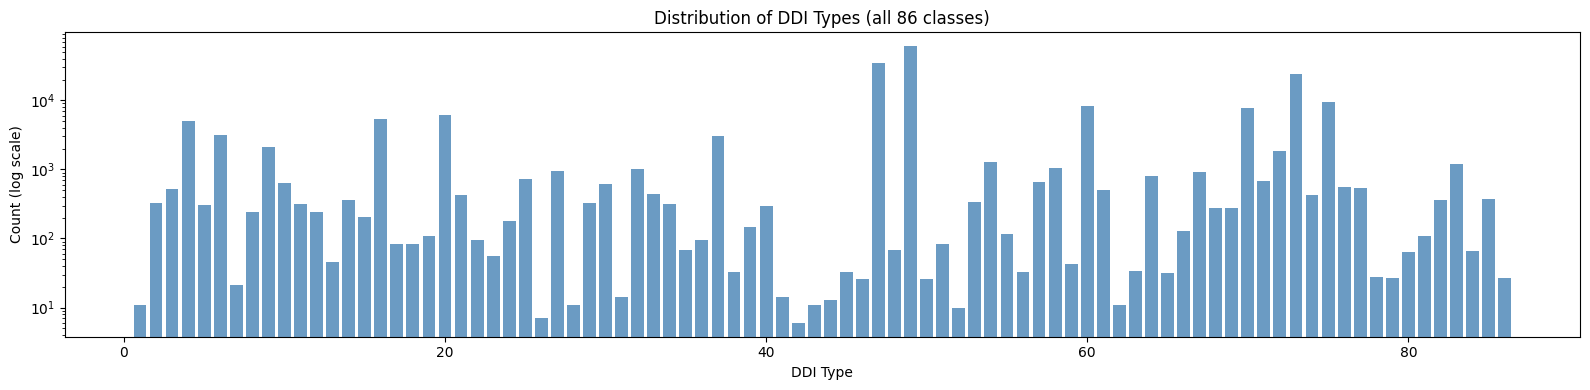

In [3]:
# ── 2.2  Inspect label distribution ────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

all_df = pd.concat([train_df, val_df, test_df])
label_counts = all_df['Y'].value_counts().sort_index()

print(f'Number of unique DDI types : {all_df["Y"].nunique()}')
print(f'Total DDI pairs            : {len(all_df):,}')

plt.figure(figsize=(16, 4))
plt.bar(label_counts.index, label_counts.values, color='steelblue', alpha=0.8)
plt.xlabel('DDI Type'); plt.ylabel('Count (log scale)')
plt.yscale('log'); plt.title('Distribution of DDI Types (all 86 classes)') ####### Right now  evaluation uses weighted F1. Weighted F1 can hide poor performance on rare classes.
plt.tight_layout(); plt.show()

In [4]:
print("Columns:", list(train_df.columns))
print("\nFirst row:")
for col in train_df.columns:
    val = train_df.iloc[0][col]
    print(f"  {col}: {str(val)[:80]}")

Columns: ['Drug1_ID', 'Drug1', 'Drug2_ID', 'Drug2', 'Y']

First row:
  Drug1_ID: DB04571
  Drug1: CC1=CC2=CC3=C(OC(=O)C=C3C)C(C)=C2O1
  Drug2_ID: DB00460
  Drug2: COC(=O)CCC1=C2NC(\C=C3/N=C(/C=C4\N\C(=C/C5=N/C(=C\2)/C(CCC(O)=O)=C5C)C(C=C)=C4C)
  Y: 1


In [5]:
import torch

# ── Correct column names from TDC ─────────────────────────────────────────────
id_col_1     = "Drug1_ID"
id_col_2     = "Drug2_ID"
smiles_col_1 = "Drug1"
smiles_col_2 = "Drug2"

# ── Use original DrugBank 86-class labels ─────────────────────────────────────
# We use Y directly because the paper does not provide the full valid 86→6 mapping.
print(f"Unique 86-class labels in train: {train_df['Y'].nunique()}")

# ── Build drug index & SMILES lookup ──────────────────────────────────────────
all_df = pd.concat([train_df, val_df, test_df])

drugs_1 = all_df[[id_col_1, smiles_col_1]].rename(
    columns={id_col_1: "drug_id", smiles_col_1: "smiles"}
)

drugs_2 = all_df[[id_col_2, smiles_col_2]].rename(
    columns={id_col_2: "drug_id", smiles_col_2: "smiles"}
)

drug_df = (
    pd.concat([drugs_1, drugs_2])
    .drop_duplicates("drug_id")
    .reset_index(drop=True)
)

drug2idx = {d: i for i, d in enumerate(drug_df["drug_id"])}
idx2smiles = dict(zip(range(len(drug_df)), drug_df["smiles"]))

N_DRUGS = len(drug2idx)

print(f"\nTotal unique drugs: {N_DRUGS:,}")

if "DB04571" in drug2idx:
    print(f'Sample — DB04571 SMILES: {idx2smiles[drug2idx["DB04571"]][:20]}...')

# ── Build train/val/test edge tensors ─────────────────────────────────────────
LABEL_COL = "Y"
USE_6_CLASSES = False

def df_to_tensors(df):
    src = torch.tensor(
        [drug2idx[d] for d in df[id_col_1]],
        dtype=torch.long
    )

    dst = torch.tensor(
        [drug2idx[d] for d in df[id_col_2]],
        dtype=torch.long
    )

    labels = torch.tensor(
        df[LABEL_COL].values-1,
        dtype=torch.long
    )

    return src, dst, labels

train_src, train_dst, train_labels = df_to_tensors(train_df)
val_src, val_dst, val_labels = df_to_tensors(val_df)
test_src, test_dst, test_labels = df_to_tensors(test_df)

CONFIG = {
    "n_classes": 86,
    "hidden_dim": 256,
    "out_dim": 128,
    "n_layers": 3,
    "dropout": 0.3,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "epochs": 10,
    "batch_size": 1024,
    "patience": 10,
}

print(f"\nPredicting {CONFIG['n_classes']} classes")
print(f"Train edges: {len(train_src):,}")
print(f"Val edges:   {len(val_src):,}")
print(f"Test edges:  {len(test_src):,}")
print(f"Train label range: {train_labels.min().item()} → {train_labels.max().item()}")

Unique 86-class labels in train: 86

Total unique drugs: 1,706
Sample — DB04571 SMILES: CC1=CC2=CC3=C(OC(=O)...

Predicting 86 classes
Train edges: 153,446
Val edges:   19,181
Test edges:  19,181
Train label range: 0 → 85


### PrimeKG

In [6]:
# ── Delete the bad file first ──────────────────────────────────────────────────
import os
if os.path.exists('primekg.csv'):
    os.remove('primekg.csv')
    print('Deleted bad file.')

# ── Download PrimeKG via TDC ───────────────────────────────────────────────────
from tdc.resource import PrimeKG

print('Downloading PrimeKG via TDC (~500MB, takes 5-10 mins)...')
pkg   = PrimeKG(path='.')
kg_df = pkg.df

print(f'\n✅ PrimeKG loaded successfully')
print(f'Shape          : {kg_df.shape}')
print(f'Columns        : {list(kg_df.columns)}')
print(f'\nRelation types:')
print(kg_df['relation'].value_counts().head(15))

Downloading...


100%|██████████| 888M/888M [00:17<00:00, 49.8MiB/s]
Loading...



✅ PrimeKG loaded successfully
Shape          : (8100498, 10)
Columns        : ['relation', 'display_relation', 'x_id', 'x_type', 'x_name', 'x_source', 'y_id', 'y_type', 'y_name', 'y_source']

Relation types:
relation
anatomy_protein_present       3036406
drug_drug                     2672628
protein_protein                642150
disease_phenotype_positive     300634
bioprocess_protein             289610
cellcomp_protein               166804
disease_protein                160822
molfunc_protein                139060
drug_effect                    129568
bioprocess_bioprocess          105772
pathway_protein                 85292
disease_disease                 64388
contraindication                61350
drug_protein                    51306
anatomy_protein_absent          39774
Name: count, dtype: int64


In [7]:
# ── Extract Drug-Protein and Protein-Protein edges ────────────────────────────

# DPI edges
dpi_kg = kg_df[kg_df['relation'] == 'drug_protein'].copy()
print(f'Raw DPI edges : {len(dpi_kg):,}')

# PPI edges
ppi_kg = kg_df[kg_df['relation'] == 'protein_protein'].copy()
print(f'Raw PPI edges : {len(ppi_kg):,}')

print(f'\nDPI columns: {list(dpi_kg.columns)}')
print(f'Sample DPI row:\n{dpi_kg.iloc[0].to_dict()}')

Raw DPI edges : 51,306
Raw PPI edges : 642,150

DPI columns: ['relation', 'display_relation', 'x_id', 'x_type', 'x_name', 'x_source', 'y_id', 'y_type', 'y_name', 'y_source']
Sample DPI row:
{'relation': 'drug_protein', 'display_relation': 'carrier', 'x_id': 'DB09130', 'x_type': 'drug', 'x_name': 'Copper', 'x_source': 'DrugBank', 'y_id': 2157, 'y_type': 'gene/protein', 'y_name': 'F8', 'y_source': 'NCBI'}


In [8]:
# ── Cell 2.6: Extract DPI and PPI edges from PrimeKG ──────────────────────────

# ── Drug-Protein Interactions ──────────────────────────────────────────────────
dpi_df = kg_df[kg_df['relation'] == 'drug_protein'].copy()
print(f'Raw DPI edges : {len(dpi_df):,}')

# Keep only drugs that exist in our DrugBank DDI dataset
dpi_df = dpi_df[dpi_df['x_id'].isin(drug2idx)].copy()
print(f'DPI edges after filtering to known drugs : {len(dpi_df):,}')

# ── Build protein index from all proteins appearing in DPI or PPI ──────────────
ppi_df = kg_df[kg_df['relation'] == 'protein_protein'].copy()
print(f'Raw PPI edges : {len(ppi_df):,}')

all_protein_ids = list(set(
    dpi_df['y_id'].tolist() +
    ppi_df['x_id'].tolist() +
    ppi_df['y_id'].tolist()
))
protein2idx = {p: i for i, p in enumerate(all_protein_ids)}
N_PROTEINS  = len(protein2idx)
print(f'Total unique proteins : {N_PROTEINS:,}')

# ── Build DPI edge tensors ─────────────────────────────────────────────────────
dpi_drug    = torch.tensor([drug2idx[d]           for d in dpi_df['x_id']], dtype=torch.long)
dpi_protein = torch.tensor([protein2idx[p]        for p in dpi_df['y_id']], dtype=torch.long)
print(f'DPI edge tensor shape : {dpi_drug.shape}')

# ── Build PPI edge tensors ─────────────────────────────────────────────────────
# Filter to proteins in our index
ppi_df = ppi_df[
    ppi_df['x_id'].isin(protein2idx) &
    ppi_df['y_id'].isin(protein2idx)
].copy()

ppi_src = torch.tensor([protein2idx[p] for p in ppi_df['x_id']], dtype=torch.long)
ppi_dst = torch.tensor([protein2idx[p] for p in ppi_df['y_id']], dtype=torch.long)
print(f'PPI edge tensor shape : {ppi_src.shape}')

# ── Build all_gene_ids for Cell 3.3 ───────────────────────────────────────────
# These are the NCBI gene IDs we need to fetch sequences for
all_gene_ids = [str(p) for p in all_protein_ids]
print(f'Total gene IDs for sequence fetching : {len(all_gene_ids):,}')

# ── Summary ────────────────────────────────────────────────────────────────────
print(f'\nCell 2.6 complete')
print(f'   drug2idx    : {len(drug2idx):,} drugs')
print(f'   protein2idx : {len(protein2idx):,} proteins')
print(f'   DPI edges   : {len(dpi_drug):,}')
print(f'   PPI edges   : {len(ppi_src):,}')
print(f'   all_gene_ids: {len(all_gene_ids):,} — used in Cell 3.3')

Raw DPI edges : 51,306
DPI edges after filtering to known drugs : 13,125
Raw PPI edges : 642,150
Total unique proteins : 29,863
DPI edge tensor shape : torch.Size([13125])
PPI edge tensor shape : torch.Size([642150])
Total gene IDs for sequence fetching : 29,863

Cell 2.6 complete
   drug2idx    : 1,706 drugs
   protein2idx : 29,863 proteins
   DPI edges   : 13,125
   PPI edges   : 642,150
   all_gene_ids: 29,863 — used in Cell 3.3


In [13]:
drugbank_drug_ids = set(drug2idx.keys())

dpi_df = kg_df[
    (kg_df["relation"] == "drug_protein") &
    (kg_df["x_type"] == "drug") &
    (kg_df["x_id"].astype(str).isin(drugbank_drug_ids))
].copy()

dpi_df["drug_id"] = dpi_df["x_id"].astype(str)
dpi_df["protein_id"] = dpi_df["y_id"].astype(str)

selected_proteins = set(dpi_df["protein_id"])

ppi_df = kg_df[
    (kg_df["relation"] == "protein_protein") &
    (kg_df["x_id"].astype(str).isin(selected_proteins)) &
    (kg_df["y_id"].astype(str).isin(selected_proteins))
].copy()

ppi_df["protein_1"] = ppi_df["x_id"].astype(str)
ppi_df["protein_2"] = ppi_df["y_id"].astype(str)

final_proteins = sorted(
    selected_proteins |
    set(ppi_df["protein_1"]) |
    set(ppi_df["protein_2"])
)

protein2idx = {pid: i for i, pid in enumerate(final_proteins)}

print("DPI edges:", len(dpi_df))
print("Final proteins:", len(protein2idx))
print("PPI edges:", len(ppi_df))

DPI edges: 13125
Final proteins: 1588
PPI edges: 13586


In [10]:

# ── Drug-Protein Interactions ──────────────────────────────────────────────────
dpi_df = kg_df[kg_df['relation'] == 'drug_protein'].copy()
print(f'Raw DPI edges : {len(dpi_df):,}')

# Map DrugBank IDs to our drug index
# PrimeKG uses DrugBank IDs in the drug column
dpi_df = dpi_df[dpi_df['x_id'].isin(drug2idx)]   # keep only drugs in our dataset
print(f'DPI edges after filtering to known drugs : {len(dpi_df):,}')

# Build protein index from PrimeKG proteins
protein_ids   = kg_df[kg_df['x_type'] == 'gene/protein']['x_id'].unique().tolist()
protein_ids  += kg_df[kg_df['y_type'] == 'gene/protein']['y_id'].unique().tolist()
protein_ids   = list(set(protein_ids))
protein2idx   = {p: i for i, p in enumerate(protein_ids)}
N_PROTEINS    = len(protein2idx)
print(f'Total unique proteins : {N_PROTEINS:,}')

# Build DPI edge tensors
dpi_drug_list    = [drug2idx[d]       for d in dpi_df['x_id'] if d in drug2idx]
dpi_protein_list = [protein2idx.get(p, -1) for p in dpi_df['y_id']]

# Filter out proteins not in our index
valid_dpi = [(d, p) for d, p in zip(dpi_drug_list, dpi_protein_list) if p != -1]
dpi_drug    = torch.tensor([x[0] for x in valid_dpi], dtype=torch.long)
dpi_protein = torch.tensor([x[1] for x in valid_dpi], dtype=torch.long)
print(f'Valid DPI edges : {len(dpi_drug):,}')

# ── Protein-Protein Interactions ───────────────────────────────────────────────
ppi_df = kg_df[kg_df['relation'] == 'protein_protein'].copy()
print(f'Raw PPI edges : {len(ppi_df):,}')

ppi_src_list = [protein2idx.get(p, -1) for p in ppi_df['x_id']]
ppi_dst_list = [protein2idx.get(p, -1) for p in ppi_df['y_id']]

valid_ppi = [(s, d) for s, d in zip(ppi_src_list, ppi_dst_list) if s != -1 and d != -1]
ppi_src = torch.tensor([x[0] for x in valid_ppi], dtype=torch.long)
ppi_dst = torch.tensor([x[1] for x in valid_ppi], dtype=torch.long)
print(f'Valid PPI edges : {len(ppi_src):,}')

# ── Protein sequences for ESM-1b ───────────────────────────────────────────────
# PrimeKG stores protein names/IDs but not sequences directly
# We need sequences from UniProt
protein_names = protein_ids   # these are gene names or UniProt IDs in PrimeKG
print(f'\nProtein IDs sample : {protein_ids[:5]}')
print('Next step: fetch sequences from UniProt for ESM-1b embedding')

Raw DPI edges : 51,306
DPI edges after filtering to known drugs : 13,125
Total unique proteins : 45,683
Valid DPI edges : 13,125
Raw PPI edges : 642,150
Valid PPI edges : 642,150

Protein IDs sample : [1, 2, 3, 131076, '96764']
Next step: fetch sequences from UniProt for ESM-1b embedding


In [15]:
ppi_df = kg_df[kg_df["relation"] == "protein_protein"].copy()
print(f"Raw PPI edges: {len(ppi_df):,}")

ppi_df["x_id"] = ppi_df["x_id"].astype(str)
ppi_df["y_id"] = ppi_df["y_id"].astype(str)

ppi_df = ppi_df[
    ppi_df["x_id"].isin(protein2idx) &
    ppi_df["y_id"].isin(protein2idx)
].reset_index(drop=True)

ppi_src = torch.tensor(
    [protein2idx[p] for p in ppi_df["x_id"]],
    dtype=torch.long
)

ppi_dst = torch.tensor(
    [protein2idx[p] for p in ppi_df["y_id"]],
    dtype=torch.long
)

print(f"Valid filtered PPI edges: {len(ppi_src):,}")

Raw PPI edges: 642,150
Valid filtered PPI edges: 13,586


## CELL FAILED.. MAYBE DELETE THIS AS IT GIVING 0 DDI EDGES.. ID Mapping is incorrect

## 🔬 Section 3: Feature Extraction

### 3.1 Drug embeddings — ChemBERTa
ChemBERTa is a BERT model pre-trained on 77M SMILES strings. We use the `[CLS]` token embedding (768-dim) as the drug node feature.

ChemBERTa reads the SMILES string and produces a 768-dimensional vector that encodes chemical meaning. So two structurally similar drugs will naturally have similar embeddings even if the model has never seen them interact with anything.

(Alternative embedding wouldve been to naively use one hot encoding that doeesnt tell us anything about the drug's chemical structures or how 2 drugs are related. Even if 2 drugs are similar in structure, one hot encoding will represent them as completely unrelated)

In [16]:
from transformers import AutoTokenizer, AutoModel
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

# Load ChemBERTa
print('Loading ChemBERTa...')
CHEMBERTA_MODEL = 'seyonec/ChemBERTa-zinc-base-v1'
chem_tokenizer = AutoTokenizer.from_pretrained(CHEMBERTA_MODEL)
chem_model     = AutoModel.from_pretrained(CHEMBERTA_MODEL).to(DEVICE)
chem_model.eval()
print('ChemBERTa loaded.')

Using device: cuda
Loading ChemBERTa...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ChemBERTa loaded.


In [17]:
@torch.no_grad()
def get_chemberta_embeddings(smiles_list, batch_size=32):
    """Returns (N, 768) tensor of CLS embeddings."""
    all_embeddings = []
    for i in range(0, len(smiles_list), batch_size):
        batch = smiles_list[i:i+batch_size]
        enc = chem_tokenizer(
            batch, padding=True, truncation=True,
            max_length=128, return_tensors='pt'
        ).to(DEVICE)
        out = chem_model(**enc)
        cls = out.last_hidden_state[:, 0, :]  # [CLS] token
        all_embeddings.append(cls.cpu())
        if (i // batch_size) % 10 == 0:
            print(f'  Processed {min(i+batch_size, len(smiles_list))}/{len(smiles_list)} drugs')
    return torch.cat(all_embeddings, dim=0)

print('Extracting ChemBERTa drug embeddings...')
smiles_list = [idx2smiles[i] for i in range(len(drug_df))]
drug_features = get_chemberta_embeddings(smiles_list)
print(f'\n✅ Drug feature matrix shape: {drug_features.shape}')  # (N_drugs, 768)

Extracting ChemBERTa drug embeddings...
  Processed 32/1706 drugs
  Processed 352/1706 drugs
  Processed 672/1706 drugs
  Processed 992/1706 drugs
  Processed 1312/1706 drugs
  Processed 1632/1706 drugs

✅ Drug feature matrix shape: torch.Size([1706, 768])


### 3.2 Chemical Similarity — RDKit Morgan Fingerprints

We compute pairwise Tanimoto similarity from Morgan fingerprints. Drug pairs with similarity > 0.7 get a **similarity edge** in the graph.

________________________________________________________
DDI edges  (from DrugBank) — "these two drugs interact"
                    
Similarity edges (from RDKit) — "these two drugs look chemically alike"

______________________________________________________________________
* Similar structure, no known interaction   → similarity edge only

* Different structure, known interaction    → DDI edge only

* Similar structure, known interaction      → both edges



In [18]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import scipy.sparse as sp

SIMILARITY_THRESHOLD = 0.7

def smiles_to_fingerprint(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)

print('Computing Morgan fingerprints...')
fps = [smiles_to_fingerprint(s) for s in smiles_list]
valid_mask = [fp is not None for fp in fps]
print(f'Valid fingerprints: {sum(valid_mask)}/{len(fps)}')

# Build sparse similarity edges
print(f'Finding similar drug pairs (threshold={SIMILARITY_THRESHOLD})...')
sim_src, sim_dst, sim_weights = [], [], []

for i in range(len(fps)):
    if fps[i] is None:
        continue
    sims = DataStructs.BulkTanimotoSimilarity(fps[i], [fps[j] for j in range(i+1, len(fps)) if fps[j] is not None])
    valid_js = [j for j in range(i+1, len(fps)) if fps[j] is not None]
    for j, s in zip(valid_js, sims):
        if s > SIMILARITY_THRESHOLD:
            sim_src.extend([i, j])
            sim_dst.extend([j, i])
            sim_weights.extend([s, s])

print(f'Similarity edges found: {len(sim_src)//2:,} pairs')
sim_src  = torch.tensor(sim_src,  dtype=torch.long)
sim_dst  = torch.tensor(sim_dst,  dtype=torch.long)
sim_weights = torch.tensor(sim_weights, dtype=torch.float)

Computing Morgan fingerprints...


[17:45:35] SMILES Parse Error: syntax error while parsing: OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1
[17:45:35] SMILES Parse Error: Failed parsing SMILES 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1' for input: 'OC1=CC=CC(=C1)C-1=C2\CCC(=N2)\C(=C2/N\C(\C=C2)=C(/C2=N/C(/C=C2)=C(\C2=CC=C\-1N2)C1=CC(O)=CC=C1)C1=CC(O)=CC=C1)\C1=CC(O)=CC=C1'


Valid fingerprints: 1705/1706
Finding similar drug pairs (threshold=0.7)...
Similarity edges found: 305 pairs


### 3.3 Protein embeddings — ESM-1b (Optional but recommended)

> ⚠️ ESM-1b requires ~7GB VRAM. On free Colab T4 (16GB), it's feasible but slow.  
> We provide a **lightweight fallback** (random embeddings) so you can test the full pipeline without ESM-1b.
> Set `USE_ESM = True` to enable real protein embeddings.

In [19]:
# ── Check what protein IDs look like in your PrimeKG ──────────────────────────
print('Sample protein IDs from PrimeKG:')
print(protein_ids[:20])

print('\nSample DPI rows from kg_df:')
dpi_sample = kg_df[kg_df['relation'] == 'drug_protein'].head(5)
print(dpi_sample[['x_id', 'x_type', 'x_name', 'y_id', 'y_type', 'y_name']].to_string())

print('\nSample protein rows:')
prot_sample = kg_df[kg_df['x_type'] == 'gene/protein'].head(5)
print(prot_sample[['x_id', 'x_type', 'x_name']].to_string())

Sample protein IDs from PrimeKG:
[1, 2, 3, 131076, '96764', 9, 10, '494334', 12, 13, 14, 15, 16, '3306', 18, 19, 20, 21, 22, 23]

Sample DPI rows from kg_df:
           x_id x_type         x_name  y_id        y_type    y_name
321075  DB09130   drug         Copper  2157  gene/protein        F8
321076  DB09130   drug         Copper  2153  gene/protein        F5
321077  DB09140   drug         Oxygen  3040  gene/protein      HBA2
321078  DB00180   drug    Flunisolide   866  gene/protein  SERPINA6
321079  DB00240   drug  Alclometasone   866  gene/protein  SERPINA6

Sample protein rows:
   x_id        x_type  x_name
0  9796  gene/protein  PHYHIP
1  7918  gene/protein  GPANK1
2  8233  gene/protein   ZRSR2
3  4899  gene/protein    NRF1
4  5297  gene/protein   PI4KA


In [20]:
import os
import json
import time
import requests

MAPPING_CACHE = "filtered_gene_to_uniprot.json"

filtered_gene_ids = [str(pid) for pid in final_proteins]

print(f"Filtered proteins to map: {len(filtered_gene_ids):,}")

if os.path.exists(MAPPING_CACHE):
    with open(MAPPING_CACHE, "r") as f:
        gene_to_uniprot = json.load(f)
    print(f"Loaded cached mapping: {len(gene_to_uniprot):,} entries")
else:
    print(f"Mapping {len(filtered_gene_ids):,} filtered gene IDs to UniProt...")
    gene_to_uniprot = {}

    for i in range(0, len(filtered_gene_ids), 100):
        batch = filtered_gene_ids[i:i+100]

        try:
            submit = requests.post(
                "https://rest.uniprot.org/idmapping/run",
                data={
                    "from": "GeneID",
                    "to": "UniProtKB-Swiss-Prot",
                    "ids": ",".join(batch),
                },
                timeout=30,
            )

            if submit.status_code != 200:
                print(f"Batch {i//100}: submit failed with {submit.status_code}")
                continue

            job_id = submit.json().get("jobId")
            if not job_id:
                print(f"Batch {i//100}: no jobId returned")
                continue

            for _ in range(30):
                time.sleep(3)
                check = requests.get(
                    f"https://rest.uniprot.org/idmapping/status/{job_id}",
                    timeout=30,
                ).json()

                if check.get("jobStatus", "") != "RUNNING":
                    break

            result = requests.get(
                f"https://rest.uniprot.org/idmapping/results/{job_id}?format=json&size=500",
                timeout=60,
            )

            if result.status_code != 200:
                print(f"Batch {i//100}: result failed with {result.status_code}")
                continue

            for entry in result.json().get("results", []):
                gene_id = str(entry["from"])
                to_data = entry["to"]

                if isinstance(to_data, dict):
                    uniprot = to_data.get("primaryAccession", "")
                elif isinstance(to_data, str):
                    uniprot = to_data
                else:
                    continue

                if uniprot:
                    gene_to_uniprot[gene_id] = uniprot

        except Exception as e:
            print(f"Batch {i//100} error: {e}")

        if (i // 100) % 10 == 0:
            with open(MAPPING_CACHE, "w") as f:
                json.dump(gene_to_uniprot, f)

            print(
                f"[{min(i+100, len(filtered_gene_ids))}/{len(filtered_gene_ids)}] "
                f"Mapped {len(gene_to_uniprot):,} so far"
            )

        time.sleep(1)

    with open(MAPPING_CACHE, "w") as f:
        json.dump(gene_to_uniprot, f)

coverage = len(gene_to_uniprot) / len(filtered_gene_ids) * 100
print(f"Final mapping: {len(gene_to_uniprot):,} / {len(filtered_gene_ids):,}")
print(f"Coverage: {coverage:.1f}%")

Filtered proteins to map: 1,588
Mapping 1,588 filtered gene IDs to UniProt...
[100/1588] Mapped 100 so far
[1100/1588] Mapped 1,094 so far
Final mapping: 1,582 / 1,588
Coverage: 99.6%


In [21]:
import requests
import time
import json
import os

SEQ_CACHE = "filtered_gene_to_sequence.json"

if os.path.exists(SEQ_CACHE):
    with open(SEQ_CACHE, "r") as f:
        gene_to_sequence = json.load(f)
    print(f"Loaded cached sequences: {len(gene_to_sequence):,}")
else:
    gene_to_sequence = {}

    items = list(gene_to_uniprot.items())
    print(f"Fetching sequences for {len(items):,} UniProt accessions...")

    for i, (gene_id, uniprot_id) in enumerate(items):
        try:
            url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta"
            r = requests.get(url, timeout=30)

            if r.status_code == 200:
                lines = r.text.strip().split("\n")
                seq = "".join(lines[1:])
                if len(seq) > 0:
                    gene_to_sequence[str(gene_id)] = seq

        except Exception as e:
            print(f"Error for {gene_id} / {uniprot_id}: {e}")

        if i % 100 == 0:
            with open(SEQ_CACHE, "w") as f:
                json.dump(gene_to_sequence, f)
            print(f"[{i}/{len(items)}] sequences saved: {len(gene_to_sequence):,}")

        time.sleep(0.2)

    with open(SEQ_CACHE, "w") as f:
        json.dump(gene_to_sequence, f)

print(f"Final sequences: {len(gene_to_sequence):,} / {len(gene_to_uniprot):,}")

Fetching sequences for 1,582 UniProt accessions...
[0/1582] sequences saved: 1
[100/1582] sequences saved: 101
[200/1582] sequences saved: 201
[300/1582] sequences saved: 301
[400/1582] sequences saved: 401
[500/1582] sequences saved: 501
[600/1582] sequences saved: 601
[700/1582] sequences saved: 701
[800/1582] sequences saved: 801
[900/1582] sequences saved: 901
[1000/1582] sequences saved: 1,001
[1100/1582] sequences saved: 1,101
[1200/1582] sequences saved: 1,201
[1300/1582] sequences saved: 1,301
[1400/1582] sequences saved: 1,401
[1500/1582] sequences saved: 1,501
Final sequences: 1,582 / 1,582


In [22]:
import torch
import esm
import os

ESM_CACHE = "filtered_protein_esm_embeddings.pt"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if os.path.exists(ESM_CACHE):
    protein_esm_dict = torch.load(ESM_CACHE, map_location="cpu")
    print(f"Loaded cached ESM embeddings: {len(protein_esm_dict):,}")
else:
    print("Loading ESM-1b...")
    esm_model, alphabet = esm.pretrained.esm1b_t33_650M_UR50S()
    esm_model = esm_model.to(DEVICE)
    esm_model.eval()
    batch_converter = alphabet.get_batch_converter()

    protein_esm_dict = {}

    items = list(gene_to_sequence.items())
    print(f"Extracting ESM embeddings for {len(items):,} proteins...")

    with torch.no_grad():
        for i, (gene_id, seq) in enumerate(items):
            try:
                # ESM-1b has practical length limits. Truncate very long sequences.
                seq = seq[:1022]

                data = [(str(gene_id), seq)]
                batch_labels, batch_strs, batch_tokens = batch_converter(data)
                batch_tokens = batch_tokens.to(DEVICE)

                results = esm_model(
                    batch_tokens,
                    repr_layers=[33],
                    return_contacts=False
                )

                token_representations = results["representations"][33]

                # Mean pooling excluding BOS/EOS
                seq_len = len(seq)
                emb = token_representations[0, 1:seq_len+1].mean(0).cpu()

                protein_esm_dict[str(gene_id)] = emb

            except Exception as e:
                print(f"ESM error for {gene_id}: {e}")

            if i % 50 == 0:
                torch.save(protein_esm_dict, ESM_CACHE)
                print(f"[{i}/{len(items)}] ESM saved: {len(protein_esm_dict):,}")

    torch.save(protein_esm_dict, ESM_CACHE)

print(f"Final ESM embeddings: {len(protein_esm_dict):,}")

Loading ESM-1b...
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/models/esm1b_t33_650M_UR50S.pt" to /root/.cache/torch/hub/checkpoints/esm1b_t33_650M_UR50S.pt
Downloading: "https://dl.fbaipublicfiles.com/fair-esm/regression/esm1b_t33_650M_UR50S-contact-regression.pt" to /root/.cache/torch/hub/checkpoints/esm1b_t33_650M_UR50S-contact-regression.pt
Extracting ESM embeddings for 1,582 proteins...
[0/1582] ESM saved: 1
[50/1582] ESM saved: 51
[100/1582] ESM saved: 101
[150/1582] ESM saved: 151
[200/1582] ESM saved: 201
[250/1582] ESM saved: 251
[300/1582] ESM saved: 301
[350/1582] ESM saved: 351
[400/1582] ESM saved: 401
[450/1582] ESM saved: 451
[500/1582] ESM saved: 501
[550/1582] ESM saved: 551
[600/1582] ESM saved: 601
[650/1582] ESM saved: 651
[700/1582] ESM saved: 701
[750/1582] ESM saved: 751
[800/1582] ESM saved: 801
[850/1582] ESM saved: 851
[900/1582] ESM saved: 901
[950/1582] ESM saved: 951
[1000/1582] ESM saved: 1,001
[1050/1582] ESM saved: 1,051
[1100/1582] ESM saved: 1

### 3.4: Extract ESM-1b protein embeddings

In [23]:
# Standardize DPI/PPI column names before ESM filtering

if "protein_id" not in dpi_df.columns:
    dpi_df["protein_id"] = dpi_df["y_id"].astype(str)

if "drug_id" not in dpi_df.columns:
    dpi_df["drug_id"] = dpi_df["x_id"].astype(str)

if "protein_1" not in ppi_df.columns:
    ppi_df["protein_1"] = ppi_df["x_id"].astype(str)

if "protein_2" not in ppi_df.columns:
    ppi_df["protein_2"] = ppi_df["y_id"].astype(str)

print("DPI columns fixed:", dpi_df.columns.tolist())
print("PPI columns fixed:", ppi_df.columns.tolist())

DPI columns fixed: ['relation', 'display_relation', 'x_id', 'x_type', 'x_name', 'x_source', 'y_id', 'y_type', 'y_name', 'y_source', 'protein_id', 'drug_id']
PPI columns fixed: ['relation', 'display_relation', 'x_id', 'x_type', 'x_name', 'x_source', 'y_id', 'y_type', 'y_name', 'y_source', 'protein_1', 'protein_2']


In [24]:
valid_proteins = set(protein_esm_dict.keys())

print("Proteins before ESM filtering:", len(final_proteins))
print("Proteins with ESM:", len(valid_proteins))

# Keep only DPI edges whose protein has ESM
dpi_df = dpi_df[dpi_df["protein_id"].isin(valid_proteins)].copy()

# Keep only PPI edges where both proteins have ESM
ppi_df = ppi_df[
    ppi_df["protein_1"].isin(valid_proteins) &
    ppi_df["protein_2"].isin(valid_proteins)
].copy()

# Rebuild final protein set after ESM filtering
final_proteins = sorted(
    set(dpi_df["protein_id"]) |
    set(ppi_df["protein_1"]) |
    set(ppi_df["protein_2"])
)

protein2idx = {pid: i for i, pid in enumerate(final_proteins)}

protein_features = torch.stack([
    protein_esm_dict[pid] for pid in final_proteins
])

N_PROTEINS = len(protein2idx)

print("Final proteins after ESM filtering:", N_PROTEINS)
print("Protein features:", protein_features.shape)
print("DPI after ESM filtering:", len(dpi_df))
print("PPI after ESM filtering:", len(ppi_df))

assert protein_features.shape[0] == N_PROTEINS
assert protein_features.shape[1] == 1280

Proteins before ESM filtering: 1588
Proteins with ESM: 1582
Final proteins after ESM filtering: 1582
Protein features: torch.Size([1582, 1280])
DPI after ESM filtering: 13118
PPI after ESM filtering: 13560


In [25]:
dpi_drug = torch.tensor(
    [drug2idx[d] for d in dpi_df["drug_id"]],
    dtype=torch.long
)

dpi_protein = torch.tensor(
    [protein2idx[p] for p in dpi_df["protein_id"]],
    dtype=torch.long
)

ppi_src = torch.tensor(
    [protein2idx[p] for p in ppi_df["protein_1"]],
    dtype=torch.long
)

ppi_dst = torch.tensor(
    [protein2idx[p] for p in ppi_df["protein_2"]],
    dtype=torch.long
)

dpi_edge_index = torch.stack([dpi_drug, dpi_protein], dim=0)
ppi_edge_index = torch.stack([ppi_src, ppi_dst], dim=0)

print("DPI edge index:", dpi_edge_index.shape)
print("PPI edge index:", ppi_edge_index.shape)

assert dpi_protein.max().item() < len(protein2idx)
assert ppi_src.max().item() < len(protein2idx)
assert ppi_dst.max().item() < len(protein2idx)
assert protein_features.shape[0] == len(protein2idx)

DPI edge index: torch.Size([2, 13118])
PPI edge index: torch.Size([2, 13560])


In [26]:
dpi_drug = torch.tensor(
    [drug2idx[d] for d in dpi_df["drug_id"]],
    dtype=torch.long
)

dpi_protein = torch.tensor(
    [protein2idx[p] for p in dpi_df["protein_id"]],
    dtype=torch.long
)

ppi_src = torch.tensor(
    [protein2idx[p] for p in ppi_df["protein_1"]],
    dtype=torch.long
)

ppi_dst = torch.tensor(
    [protein2idx[p] for p in ppi_df["protein_2"]],
    dtype=torch.long
)

dpi_edge_index = torch.stack([dpi_drug, dpi_protein], dim=0)
ppi_edge_index = torch.stack([ppi_src, ppi_dst], dim=0)

print("DPI edge index:", dpi_edge_index.shape)
print("PPI edge index:", ppi_edge_index.shape)

assert dpi_protein.max().item() < len(protein2idx)
assert ppi_src.max().item() < len(protein2idx)
assert ppi_dst.max().item() < len(protein2idx)
assert protein_features.shape[0] == len(protein2idx)

DPI edge index: torch.Size([2, 13118])
PPI edge index: torch.Size([2, 13560])


In [27]:
assert drug_features.shape[0] == len(drug2idx)
assert drug_features.shape[1] == 768

In [28]:
print("Similarity edges:", len(sim_src))

assert max(sim_src).item() < len(drug2idx)
assert max(sim_dst).item() < len(drug2idx)

Similarity edges: 610


## 🕸️ Section 4: Build the Heterogeneous Graph

The graph has:
- **Node types**: `drug`, `protein`
- **Edge types**: `drug-drug` (DDI), `drug-protein` (DPI), `protein-protein` (PPI), `drug-similar-drug` (similarity)

In [29]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

drug_feats_dev = drug_features.float().to(DEVICE)
prot_feats_dev = protein_features.float().to(DEVICE)

N_DRUGS = len(drug2idx)
N_PROTEINS = len(protein2idx)

def edge_to_adj(src, dst, n_src, n_dst, device):
    src = src.to(device)
    dst = dst.to(device)

    indices = torch.stack([src, dst], dim=0)
    values = torch.ones(indices.shape[1], device=device)

    adj = torch.sparse_coo_tensor(
        indices,
        values,
        size=(n_src, n_dst),
        device=device
    )

    return adj.coalesce()

# DDI: train edges only, bidirectional
train_ddi_src = torch.cat([train_src, train_dst])
train_ddi_dst = torch.cat([train_dst, train_src])

A_ddi = edge_to_adj(
    train_ddi_src,
    train_ddi_dst,
    N_DRUGS,
    N_DRUGS,
    DEVICE
)

# DPI and reverse DPI
A_dpi = edge_to_adj(
    dpi_drug,
    dpi_protein,
    N_DRUGS,
    N_PROTEINS,
    DEVICE
)

A_rdpi = edge_to_adj(
    dpi_protein,
    dpi_drug,
    N_PROTEINS,
    N_DRUGS,
    DEVICE
)

# PPI: bidirectional
ppi_src_bi = torch.cat([ppi_src, ppi_dst])
ppi_dst_bi = torch.cat([ppi_dst, ppi_src])

A_ppi = edge_to_adj(
    ppi_src_bi,
    ppi_dst_bi,
    N_PROTEINS,
    N_PROTEINS,
    DEVICE
)

# Similarity edges
A_sim = edge_to_adj(
    sim_src,
    sim_dst,
    N_DRUGS,
    N_DRUGS,
    DEVICE
)

print("A_ddi:", A_ddi.shape, A_ddi._nnz())
print("A_dpi:", A_dpi.shape, A_dpi._nnz())
print("A_rdpi:", A_rdpi.shape, A_rdpi._nnz())
print("A_ppi:", A_ppi.shape, A_ppi._nnz())
print("A_sim:", A_sim.shape, A_sim._nnz())

A_ddi: torch.Size([1706, 1706]) 306374
A_dpi: torch.Size([1706, 1582]) 13023
A_rdpi: torch.Size([1582, 1706]) 13023
A_ppi: torch.Size([1582, 1582]) 13560
A_sim: torch.Size([1706, 1706]) 610


In [30]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

drug_feats_dev = drug_features.float().to(DEVICE)
prot_feats_dev = protein_features.float().to(DEVICE)

N_DRUGS = len(drug2idx)
N_PROTEINS = len(protein2idx)

def edge_to_adj(src, dst, n_src, n_dst, device):
    src = src.to(device)
    dst = dst.to(device)

    indices = torch.stack([src, dst], dim=0)
    values = torch.ones(indices.shape[1], device=device)

    adj = torch.sparse_coo_tensor(
        indices,
        values,
        size=(n_src, n_dst),
        device=device
    )

    return adj.coalesce()

# DDI: train edges only, bidirectional
train_ddi_src = torch.cat([train_src, train_dst])
train_ddi_dst = torch.cat([train_dst, train_src])

A_ddi = edge_to_adj(
    train_ddi_src,
    train_ddi_dst,
    N_DRUGS,
    N_DRUGS,
    DEVICE
)

# DPI and reverse DPI
A_dpi = edge_to_adj(
    dpi_drug,
    dpi_protein,
    N_DRUGS,
    N_PROTEINS,
    DEVICE
)

A_rdpi = edge_to_adj(
    dpi_protein,
    dpi_drug,
    N_PROTEINS,
    N_DRUGS,
    DEVICE
)

# PPI: bidirectional
ppi_src_bi = torch.cat([ppi_src, ppi_dst])
ppi_dst_bi = torch.cat([ppi_dst, ppi_src])

A_ppi = edge_to_adj(
    ppi_src_bi,
    ppi_dst_bi,
    N_PROTEINS,
    N_PROTEINS,
    DEVICE
)

# Similarity edges
# Optional: make similarity bidirectional too
sim_src_bi = torch.cat([sim_src, sim_dst])
sim_dst_bi = torch.cat([sim_dst, sim_src])

A_sim = edge_to_adj(
    sim_src_bi,
    sim_dst_bi,
    N_DRUGS,
    N_DRUGS,
    DEVICE
)

print("A_ddi:", A_ddi.shape, A_ddi._nnz())
print("A_dpi:", A_dpi.shape, A_dpi._nnz())
print("A_rdpi:", A_rdpi.shape, A_rdpi._nnz())
print("A_ppi:", A_ppi.shape, A_ppi._nnz())
print("A_sim:", A_sim.shape, A_sim._nnz())

# Important sanity checks
assert A_dpi._nnz() <= dpi_edge_index.shape[1]
assert A_rdpi._nnz() <= dpi_edge_index.shape[1]
assert A_ppi._nnz() <= ppi_edge_index.shape[1] * 2

A_ddi: torch.Size([1706, 1706]) 306374
A_dpi: torch.Size([1706, 1582]) 13023
A_rdpi: torch.Size([1582, 1706]) 13023
A_ppi: torch.Size([1582, 1582]) 13560
A_sim: torch.Size([1706, 1706]) 610


In [ ]:
print("Labels:", train_labels.min().item(), train_labels.max().item())
print("Classes:", CONFIG["n_classes"])
assert train_labels.min().item() >= 0
assert train_labels.max().item() < CONFIG["n_classes"]
assert val_labels.max().item() < CONFIG["n_classes"]
assert test_labels.max().item() < CONFIG["n_classes"]
print("Ready to train.")

Labels: 0 85
Classes: 86
Ready to train.


## 🧠 Section 5: Define the HGCN-DDI Model

Architecture:
1. **HeteroGraphConv** with GCN aggregation — 3 layers
2. Concatenate drug pair embeddings → **MLP** classifier

In [32]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("Using existing adjacency matrices from Step 13")
print("A_ddi :", A_ddi.shape, A_ddi._nnz())
print("A_dpi :", A_dpi.shape, A_dpi._nnz())
print("A_rdpi:", A_rdpi.shape, A_rdpi._nnz())
print("A_ppi :", A_ppi.shape, A_ppi._nnz())
print("A_sim :", A_sim.shape, A_sim._nnz())


class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)

    def forward(self, A, H):
        return self.W(torch.sparse.mm(A, H))


class HGCN_DDI(nn.Module):
    def __init__(self, in_drug, in_prot, hidden, out, n_classes, n_layers=3, dropout=0.3):
        super().__init__()

        self.drug_proj = nn.Linear(in_drug, hidden)
        self.prot_proj = nn.Linear(in_prot, hidden)

        self.gcn = nn.ModuleList([
            nn.ModuleDict({
                "ddi": GCNLayer(hidden, hidden),
                "dpi": GCNLayer(hidden, hidden),
                "rdpi": GCNLayer(hidden, hidden),
                "ppi": GCNLayer(hidden, hidden),
                "sim": GCNLayer(hidden, hidden),
            })
            for _ in range(n_layers)
        ])

        self.drug_bn = nn.ModuleList([
            nn.BatchNorm1d(hidden) for _ in range(n_layers)
        ])

        self.prot_bn = nn.ModuleList([
            nn.BatchNorm1d(hidden) for _ in range(n_layers)
        ])

        self.out_proj = nn.Linear(hidden, out)

        self.mlp = nn.Sequential(
            nn.Linear(out * 4, out),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(out, out // 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(out // 2, n_classes)
        )

        self.drop = nn.Dropout(dropout)

    def encode(self, drug_feats, prot_feats):
        h_drug = F.relu(self.drug_proj(drug_feats))
        h_prot = F.relu(self.prot_proj(prot_feats))

        for i, layer in enumerate(self.gcn):
            drug_msg = (
                layer["ddi"](A_ddi, h_drug)
                + layer["dpi"](A_dpi, h_prot)
                + layer["sim"](A_sim, h_drug)
            )

            prot_msg = (
                layer["ppi"](A_ppi, h_prot)
                + layer["rdpi"](A_rdpi, h_drug)
            )

            # Residual connection
            h_drug = self.drop(F.relu(self.drug_bn[i](drug_msg + h_drug)))
            h_prot = self.drop(F.relu(self.prot_bn[i](prot_msg + h_prot)))

        return self.out_proj(h_drug)

    def forward(self, drug_feats, prot_feats, src, dst):
        emb = self.encode(drug_feats, prot_feats)

        h_i = emb[src]
        h_j = emb[dst]

        pair = torch.cat([
            h_i,
            h_j,
            torch.abs(h_i - h_j),
            h_i * h_j
        ], dim=-1)

        return self.mlp(pair)


# Feature tensors should already exist after Step 13
drug_feats_dev = drug_features.float().to(DEVICE)
prot_feats_dev = protein_features.float().to(DEVICE)

model = HGCN_DDI(
    in_drug=drug_features.shape[1],
    in_prot=protein_features.shape[1],
    hidden=CONFIG["hidden_dim"],
    out=CONFIG["out_dim"],
    n_classes=CONFIG["n_classes"],
    n_layers=CONFIG["n_layers"],
    dropout=CONFIG["dropout"],
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5
)

criterion = nn.CrossEntropyLoss()

total = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Device: {DEVICE}")
print(f"Classes: {CONFIG['n_classes']}")
print(f"Drug features: {drug_feats_dev.shape}")
print(f"Protein features: {prot_feats_dev.shape}")
print(f"Model parameters: {total:,}")
print("MODEL READY!!!")

Using existing adjacency matrices from Step 13
A_ddi : torch.Size([1706, 1706]) 306374
A_dpi : torch.Size([1706, 1582]) 13023
A_rdpi: torch.Size([1582, 1706]) 13023
A_ppi : torch.Size([1582, 1582]) 13560
A_sim : torch.Size([1706, 1706]) 610
Device: cuda
Classes: 86
Drug features: torch.Size([1706, 768])
Protein features: torch.Size([1582, 1280])
Model parameters: 1,623,318
MODEL READY!!!


In [33]:
def hits_at_k_from_logits(logits, labels, k):
    """
    logits: [batch_size, num_classes]
    labels: [batch_size]
    Returns number of correct top-k hits and total samples.
    """
    k = min(k, logits.shape[1])  # avoid k > number of classes
    topk_preds = torch.topk(logits, k=k, dim=1).indices
    hits = topk_preds.eq(labels.view(-1, 1)).any(dim=1)
    return hits.float().sum().item(), labels.size(0)

In [41]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from torch.utils.data import DataLoader, TensorDataset
import torch

def hits_at_k_from_logits(logits, labels, k):
    """
    Checks whether the true class is inside the model's top-k predicted classes.
    """
    k = min(k, logits.shape[1])
    topk_preds = torch.topk(logits, k=k, dim=1).indices
    hits = topk_preds.eq(labels.view(-1, 1)).any(dim=1)
    return hits.float().sum().item(), labels.size(0)


def evaluate(model, src, dst, labels):
    model.eval()

    all_preds = []
    all_true = []

    hits1 = 0
    hits3 = 0
    hits5 = 0
    hits10 = 0
    total = 0

    loader = DataLoader(
        TensorDataset(src, dst, labels),
        batch_size=CONFIG["batch_size"],
        shuffle=False
    )

    with torch.no_grad():
        for s, d, y in loader:
            s = s.to(DEVICE)
            d = d.to(DEVICE)
            y = y.to(DEVICE)

            logits = model(drug_feats_dev, prot_feats_dev, s, d)
            preds = logits.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_true.append(y.cpu())

            c1, n = hits_at_k_from_logits(logits, y, k=1)
            c3, _ = hits_at_k_from_logits(logits, y, k=3)
            c5, _ = hits_at_k_from_logits(logits, y, k=5)
            c10, _ = hits_at_k_from_logits(logits, y, k=10)

            hits1 += c1
            hits3 += c3
            hits5 += c5
            hits10 += c10
            total += n

    preds = torch.cat(all_preds).numpy()
    true = torch.cat(all_true).numpy()

    return {
        "accuracy": accuracy_score(true, preds) * 100,
        "weighted_f1": f1_score(true, preds, average="weighted", zero_division=0) * 100,
        "macro_f1": f1_score(true, preds, average="macro", zero_division=0) * 100,
        "precision": precision_score(true, preds, average="weighted", zero_division=0) * 100,
        "recall": recall_score(true, preds, average="weighted", zero_division=0) * 100,
        "hits@1": hits1 / total * 100,
        "hits@3": hits3 / total * 100,
        "hits@5": hits5 / total * 100,
        "hits@10": hits10 / total * 100,
    }

print("Evaluation function with Hits@K ready.")

Evaluation function with Hits@K ready.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from torch.utils.data import DataLoader, TensorDataset

def evaluate(model, src, dst, labels):
    model.eval()

    all_preds = []
    all_true = []

    loader = DataLoader(
        TensorDataset(src, dst, labels),
        batch_size=CONFIG["batch_size"],
        shuffle=False
    )

    with torch.no_grad():
        for s, d, y in loader:
            s = s.to(DEVICE)
            d = d.to(DEVICE)

            logits = model(drug_feats_dev, prot_feats_dev, s, d)
            preds = logits.argmax(dim=1).cpu()

            all_preds.append(preds)
            all_true.append(y.cpu())

    preds = torch.cat(all_preds).numpy()
    true = torch.cat(all_true).numpy()

    return {
        "accuracy": accuracy_score(true, preds) * 100,
        "weighted_f1": f1_score(true, preds, average="weighted", zero_division=0) * 100,
        "macro_f1": f1_score(true, preds, average="macro", zero_division=0) * 100,
        "precision": precision_score(true, preds, average="weighted", zero_division=0) * 100,
        "recall": recall_score(true, preds, average="weighted", zero_division=0) * 100,
    }

print("Evaluation function ready.")

Evaluation function ready.


In [35]:
print("CONFIG n_classes:", CONFIG["n_classes"])

print("Train min/max:", train_labels.min().item(), train_labels.max().item())
print("Val min/max:", val_labels.min().item(), val_labels.max().item())
print("Test min/max:", test_labels.min().item(), test_labels.max().item())

print("Unique train labels:", len(torch.unique(train_labels)))
print("Unique val labels:", len(torch.unique(val_labels)))
print("Unique test labels:", len(torch.unique(test_labels)))

CONFIG n_classes: 86
Train min/max: 0 85
Val min/max: 0 85
Test min/max: 0 85
Unique train labels: 86
Unique val labels: 82
Unique test labels: 84


In [36]:
train_src, train_dst, train_labels = df_to_tensors(train_df)
val_src, val_dst, val_labels = df_to_tensors(val_df)
test_src, test_dst, test_labels = df_to_tensors(test_df)

In [37]:
print("CONFIG n_classes:", CONFIG["n_classes"])

print("Train min/max:", train_labels.min().item(), train_labels.max().item())
print("Val min/max:", val_labels.min().item(), val_labels.max().item())
print("Test min/max:", test_labels.min().item(), test_labels.max().item())

print("Unique train labels:", len(torch.unique(train_labels)))
print("Unique val labels:", len(torch.unique(val_labels)))
print("Unique test labels:", len(torch.unique(test_labels)))

CONFIG n_classes: 86
Train min/max: 0 85
Val min/max: 0 85
Test min/max: 0 85
Unique train labels: 86
Unique val labels: 82
Unique test labels: 84


In [42]:
train_dataset = TensorDataset(train_src, train_dst, train_labels)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True
)

best_val_f1 = 0
best_state = None
patience_counter = 0

history = {
    "loss": [],
    "val_weighted_f1": [],
    "val_macro_f1": [],
    "val_acc": []
}

print(f"\nTraining for {CONFIG['epochs']} epochs...\n")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val W-F1':>10} | {'Val M-F1':>10} | {'Val Acc':>9}")
print("-" * 65)

for epoch in range(1, 20):
    model.train()
    total_loss = 0

    for s, d, y in train_loader:
        s = s.to(DEVICE)
        d = d.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        logits = model(drug_feats_dev, prot_feats_dev, s, d)
        loss = criterion(logits, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * len(y)

    avg_loss = total_loss / len(train_dataset)

    val_metrics = evaluate(model, val_src, val_dst, val_labels)

    scheduler.step(val_metrics["weighted_f1"])

    history["loss"].append(avg_loss)
    history["val_weighted_f1"].append(val_metrics["weighted_f1"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])
    history["val_acc"].append(val_metrics["accuracy"])

    print(
        f"{epoch:>6} | "
        f"{avg_loss:>10.4f} | "
        f"{val_metrics['weighted_f1']:>9.2f}% | "
        f"{val_metrics['macro_f1']:>9.2f}% | "
        f"{val_metrics['accuracy']:>8.2f}%"
    )

    if val_metrics["weighted_f1"] > best_val_f1:
        best_val_f1 = val_metrics["weighted_f1"]
        best_state = {
            k: v.cpu().clone()
            for k, v in model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= CONFIG["patience"]:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\nBest validation weighted F1: {best_val_f1:.2f}%")


Training for 10 epochs...

 Epoch | Train Loss |   Val W-F1 |   Val M-F1 |   Val Acc
-----------------------------------------------------------------
     1 |     1.1815 |     52.56% |     14.40% |    58.99%
     2 |     1.0610 |     68.51% |     28.57% |    71.95%
     3 |     0.9834 |     44.38% |     10.59% |    51.33%
     4 |     0.9189 |     50.81% |     21.46% |    52.97%
     5 |     0.8664 |     33.68% |     12.19% |    32.29%
     6 |     0.8238 |     39.57% |      8.60% |    43.60%
     7 |     0.7887 |     32.21% |     12.85% |    29.70%
     8 |     0.7553 |     40.62% |     16.48% |    47.39%
     9 |     0.6963 |     57.65% |     26.79% |    61.82%
    10 |     0.6725 |     69.10% |     38.59% |    70.27%
    11 |     0.6570 |     63.32% |     36.68% |    65.39%
    12 |     0.6437 |     36.12% |     23.09% |    33.31%
    13 |     0.6284 |     72.96% |     40.91% |    75.25%
    14 |     0.6158 |     66.53% |     34.49% |    70.14%
    15 |     0.6041 |     69.05% |  

In [43]:
test_metrics = evaluate(model, test_src, test_dst, test_labels)

print(f"Accuracy    : {test_metrics['accuracy']:.2f}%")
print(f"Weighted F1 : {test_metrics['weighted_f1']:.2f}%")
print(f"Macro F1    : {test_metrics['macro_f1']:.2f}%")
print(f"Precision   : {test_metrics['precision']:.2f}%")
print(f"Recall      : {test_metrics['recall']:.2f}%")
print(f"Hits@1      : {test_metrics['hits@1']:.2f}%")
print(f"Hits@3      : {test_metrics['hits@3']:.2f}%")
print(f"Hits@5      : {test_metrics['hits@5']:.2f}%")
print(f"Hits@10     : {test_metrics['hits@10']:.2f}%")

Accuracy    : 67.70%
Weighted F1 : 64.31%
Macro F1    : 28.24%
Precision   : 68.00%
Recall      : 67.70%
Hits@1      : 67.70%
Hits@3      : 91.46%
Hits@5      : 95.75%
Hits@10     : 98.48%


In [ ]:
model.load_state_dict({
    k: v.to(DEVICE)
    for k, v in best_state.items()
})

test_metrics = evaluate(model, test_src, test_dst, test_labels)

print("=" * 55)
print("HGCN-DDI Test Results")
print("=" * 55)
print(f"Accuracy    : {test_metrics['accuracy']:.2f}%")
print(f"Weighted F1 : {test_metrics['weighted_f1']:.2f}%")
print(f"Macro F1    : {test_metrics['macro_f1']:.2f}%")
print(f"Precision   : {test_metrics['precision']:.2f}%")
print(f"Recall      : {test_metrics['recall']:.2f}%")
print("=" * 55)

HGCN-DDI Test Results
Accuracy    : 82.21%
Weighted F1 : 81.48%
Macro F1    : 50.06%
Precision   : 81.83%
Recall      : 82.21%


### Experiment 02

In [44]:
CONFIG["lr"] = 3e-4
CONFIG["epochs"] = 30
CONFIG["patience"] = 8

import torch
import torch.nn as nn
import torch.nn.functional as F

print("Using existing adjacency matrices from Step 13")
print("A_ddi :", A_ddi.shape, A_ddi._nnz())
print("A_dpi :", A_dpi.shape, A_dpi._nnz())
print("A_rdpi:", A_rdpi.shape, A_rdpi._nnz())
print("A_ppi :", A_ppi.shape, A_ppi._nnz())
print("A_sim :", A_sim.shape, A_sim._nnz())


class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)

    def forward(self, A, H):
        return self.W(torch.sparse.mm(A, H))


class HGCN_DDI_LayerNorm(nn.Module):
    def __init__(self, in_drug, in_prot, hidden, out, n_classes, n_layers=3, dropout=0.3):
        super().__init__()

        self.drug_proj = nn.Linear(in_drug, hidden)
        self.prot_proj = nn.Linear(in_prot, hidden)

        self.gcn = nn.ModuleList([
            nn.ModuleDict({
                "ddi": GCNLayer(hidden, hidden),
                "dpi": GCNLayer(hidden, hidden),
                "rdpi": GCNLayer(hidden, hidden),
                "ppi": GCNLayer(hidden, hidden),
                "sim": GCNLayer(hidden, hidden),
            })
            for _ in range(n_layers)
        ])

        # Changed from BatchNorm1d to LayerNorm
        self.drug_norm = nn.ModuleList([
            nn.LayerNorm(hidden) for _ in range(n_layers)
        ])

        self.prot_norm = nn.ModuleList([
            nn.LayerNorm(hidden) for _ in range(n_layers)
        ])

        self.out_proj = nn.Linear(hidden, out)

        self.mlp = nn.Sequential(
            nn.Linear(out * 4, out),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(out, out // 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(out // 2, n_classes)
        )

        self.drop = nn.Dropout(dropout)

    def encode(self, drug_feats, prot_feats):
        h_drug = F.relu(self.drug_proj(drug_feats))
        h_prot = F.relu(self.prot_proj(prot_feats))

        for i, layer in enumerate(self.gcn):
            drug_msg = (
                layer["ddi"](A_ddi, h_drug)
                + layer["dpi"](A_dpi, h_prot)
                + layer["sim"](A_sim, h_drug)
            )

            prot_msg = (
                layer["ppi"](A_ppi, h_prot)
                + layer["rdpi"](A_rdpi, h_drug)
            )

            # Residual + LayerNorm
            h_drug = self.drop(F.relu(self.drug_norm[i](drug_msg + h_drug)))
            h_prot = self.drop(F.relu(self.prot_norm[i](prot_msg + h_prot)))

        return self.out_proj(h_drug)

    def forward(self, drug_feats, prot_feats, src, dst):
        emb = self.encode(drug_feats, prot_feats)

        h_i = emb[src]
        h_j = emb[dst]

        pair = torch.cat([
            h_i,
            h_j,
            torch.abs(h_i - h_j),
            h_i * h_j
        ], dim=-1)

        return self.mlp(pair)


drug_feats_dev = drug_features.float().to(DEVICE)
prot_feats_dev = protein_features.float().to(DEVICE)

model = HGCN_DDI_LayerNorm(
    in_drug=drug_features.shape[1],
    in_prot=protein_features.shape[1],
    hidden=CONFIG["hidden_dim"],
    out=CONFIG["out_dim"],
    n_classes=CONFIG["n_classes"],
    n_layers=CONFIG["n_layers"],
    dropout=CONFIG["dropout"],
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5
)

criterion = nn.CrossEntropyLoss()

total = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Device: {DEVICE}")
print(f"Classes: {CONFIG['n_classes']}")
print(f"LR: {CONFIG['lr']}")
print(f"Epochs: {CONFIG['epochs']}")
print(f"Drug features: {drug_feats_dev.shape}")
print(f"Protein features: {prot_feats_dev.shape}")
print(f"Model parameters: {total:,}")
print("LAYER-NORM MODEL READY!!!")

Using existing adjacency matrices from Step 13
A_ddi : torch.Size([1706, 1706]) 306374
A_dpi : torch.Size([1706, 1582]) 13023
A_rdpi: torch.Size([1582, 1706]) 13023
A_ppi : torch.Size([1582, 1582]) 13560
A_sim : torch.Size([1706, 1706]) 610
Device: cuda
Classes: 86
LR: 0.0003
Epochs: 30
Drug features: torch.Size([1706, 768])
Protein features: torch.Size([1582, 1280])
Model parameters: 1,623,318
LAYER-NORM MODEL READY!!!


In [45]:
train_dataset = TensorDataset(train_src, train_dst, train_labels)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True
)

best_val_f1 = 0
best_state = None
patience_counter = 0

history = {
    "loss": [],
    "val_weighted_f1": [],
    "val_macro_f1": [],
    "val_acc": []
}

print(f"\nTraining for {CONFIG['epochs']} epochs...\n")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val W-F1':>10} | {'Val M-F1':>10} | {'Val Acc':>9}")
print("-" * 65)

for epoch in range(1, 30):
    model.train()
    total_loss = 0

    for s, d, y in train_loader:
        s = s.to(DEVICE)
        d = d.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        logits = model(drug_feats_dev, prot_feats_dev, s, d)
        loss = criterion(logits, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * len(y)

    avg_loss = total_loss / len(train_dataset)

    val_metrics = evaluate(model, val_src, val_dst, val_labels)

    scheduler.step(val_metrics["weighted_f1"])

    history["loss"].append(avg_loss)
    history["val_weighted_f1"].append(val_metrics["weighted_f1"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])
    history["val_acc"].append(val_metrics["accuracy"])

    print(
        f"{epoch:>6} | "
        f"{avg_loss:>10.4f} | "
        f"{val_metrics['weighted_f1']:>9.2f}% | "
        f"{val_metrics['macro_f1']:>9.2f}% | "
        f"{val_metrics['accuracy']:>8.2f}%"
    )

    if val_metrics["weighted_f1"] > best_val_f1:
        best_val_f1 = val_metrics["weighted_f1"]
        best_state = {
            k: v.cpu().clone()
            for k, v in model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= CONFIG["patience"]:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\nBest validation weighted F1: {best_val_f1:.2f}%")


Training for 30 epochs...

 Epoch | Train Loss |   Val W-F1 |   Val M-F1 |   Val Acc
-----------------------------------------------------------------
     1 |     2.8555 |     15.24% |      0.59% |    31.67%
     2 |     2.3719 |     30.03% |      1.51% |    43.13%
     3 |     2.0335 |     38.50% |      3.39% |    47.43%
     4 |     1.8417 |     42.33% |      6.05% |    50.19%
     5 |     1.6809 |     48.56% |      8.42% |    54.57%
     6 |     1.5714 |     52.13% |     10.89% |    57.31%
     7 |     1.5115 |     53.24% |     12.92% |    58.04%
     8 |     1.4490 |     54.17% |     14.29% |    59.61%
     9 |     1.3915 |     56.64% |     16.41% |    61.32%
    10 |     1.3427 |     59.35% |     18.81% |    63.47%
    11 |     1.3012 |     58.07% |     19.14% |    62.39%
    12 |     1.2638 |     60.06% |     20.91% |    64.89%
    13 |     1.2341 |     62.56% |     23.04% |    66.12%
    14 |     1.1885 |     64.75% |     24.38% |    67.61%
    15 |     1.1610 |     64.64% |  

In [46]:
test_metrics = evaluate(model, test_src, test_dst, test_labels)

print(f"Accuracy    : {test_metrics['accuracy']:.2f}%")
print(f"Weighted F1 : {test_metrics['weighted_f1']:.2f}%")
print(f"Macro F1    : {test_metrics['macro_f1']:.2f}%")
print(f"Precision   : {test_metrics['precision']:.2f}%")
print(f"Recall      : {test_metrics['recall']:.2f}%")
print(f"Hits@1      : {test_metrics['hits@1']:.2f}%")
print(f"Hits@3      : {test_metrics['hits@3']:.2f}%")
print(f"Hits@5      : {test_metrics['hits@5']:.2f}%")
print(f"Hits@10     : {test_metrics['hits@10']:.2f}%")

Accuracy    : 78.62%
Weighted F1 : 76.54%
Macro F1    : 38.88%
Precision   : 77.46%
Recall      : 78.62%
Hits@1      : 78.62%
Hits@3      : 95.52%
Hits@5      : 97.89%
Hits@10     : 99.36%


In [ ]:
model.load_state_dict({
    k: v.to(DEVICE)
    for k, v in best_state.items()
})

test_metrics_exp2 = evaluate(model, test_src, test_dst, test_labels)

print("=" * 55)
print("Experiment 2: LayerNorm Test Results")
print("=" * 55)
print(f"Accuracy    : {test_metrics_exp2['accuracy']:.2f}%")
print(f"Weighted F1 : {test_metrics_exp2['weighted_f1']:.2f}%")
print(f"Macro F1    : {test_metrics_exp2['macro_f1']:.2f}%")
print(f"Precision   : {test_metrics_exp2['precision']:.2f}%")
print(f"Recall      : {test_metrics_exp2['recall']:.2f}%")
print("=" * 55)

Experiment 2: LayerNorm Test Results
Accuracy    : 78.89%
Weighted F1 : 77.26%
Macro F1    : 41.25%
Precision   : 77.75%
Recall      : 78.89%


## Experiment 3

Experiment 3:
BatchNorm + residual + 2 GCN layers

In [47]:
# ── Experiment 3 config: BatchNorm + Residual + 2-layer HGCN ────────────────

CONFIG["n_layers"] = 2
CONFIG["lr"] = 1e-3
CONFIG["epochs"] = 20
CONFIG["patience"] = 8

print("Experiment 3 config:")
print(CONFIG)

Experiment 3 config:
{'n_classes': 86, 'hidden_dim': 256, 'out_dim': 128, 'n_layers': 2, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001, 'epochs': 20, 'batch_size': 1024, 'patience': 8}


In [49]:
import torch
import torch.nn as nn
import torch.nn.functional as F

print("Experiment 3: BatchNorm + Residual + 2-layer HGCN")
print("Using existing adjacency matrices")
print("A_ddi :", A_ddi.shape, A_ddi._nnz())
print("A_dpi :", A_dpi.shape, A_dpi._nnz())
print("A_rdpi:", A_rdpi.shape, A_rdpi._nnz())
print("A_ppi :", A_ppi.shape, A_ppi._nnz())
print("A_sim :", A_sim.shape, A_sim._nnz())


class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Linear(in_dim, out_dim, bias=False)

    def forward(self, A, H):
        return self.W(torch.sparse.mm(A, H))


class HGCN_DDI_Exp3(nn.Module):
    def __init__(self, in_drug, in_prot, hidden, out, n_classes, n_layers=2, dropout=0.3):
        super().__init__()

        self.drug_proj = nn.Linear(in_drug, hidden)
        self.prot_proj = nn.Linear(in_prot, hidden)

        self.gcn = nn.ModuleList([
            nn.ModuleDict({
                "ddi": GCNLayer(hidden, hidden),
                "dpi": GCNLayer(hidden, hidden),
                "rdpi": GCNLayer(hidden, hidden),
                "ppi": GCNLayer(hidden, hidden),
                "sim": GCNLayer(hidden, hidden),
            })
            for _ in range(n_layers)
        ])

        # Same as Experiment 1: BatchNorm
        self.drug_bn = nn.ModuleList([
            nn.BatchNorm1d(hidden) for _ in range(n_layers)
        ])

        self.prot_bn = nn.ModuleList([
            nn.BatchNorm1d(hidden) for _ in range(n_layers)
        ])

        self.out_proj = nn.Linear(hidden, out)

        # Same strong pair representation:
        # [h_i, h_j, |h_i-h_j|, h_i*h_j]
        self.mlp = nn.Sequential(
            nn.Linear(out * 4, out),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(out, out // 2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(out // 2, n_classes)
        )

        self.drop = nn.Dropout(dropout)

    def encode(self, drug_feats, prot_feats):
        h_drug = F.relu(self.drug_proj(drug_feats))
        h_prot = F.relu(self.prot_proj(prot_feats))

        for i, layer in enumerate(self.gcn):
            drug_msg = (
                layer["ddi"](A_ddi, h_drug)
                + layer["dpi"](A_dpi, h_prot)
                + layer["sim"](A_sim, h_drug)
            )

            prot_msg = (
                layer["ppi"](A_ppi, h_prot)
                + layer["rdpi"](A_rdpi, h_drug)
            )

            # Residual connection + BatchNorm
            h_drug = self.drop(F.relu(self.drug_bn[i](drug_msg + h_drug)))
            h_prot = self.drop(F.relu(self.prot_bn[i](prot_msg + h_prot)))

        return self.out_proj(h_drug)

    def forward(self, drug_feats, prot_feats, src, dst):
        emb = self.encode(drug_feats, prot_feats)

        h_i = emb[src]
        h_j = emb[dst]

        pair = torch.cat([
            h_i,
            h_j,
            torch.abs(h_i - h_j),
            h_i * h_j
        ], dim=-1)

        return self.mlp(pair)


drug_feats_dev = drug_features.float().to(DEVICE)
prot_feats_dev = protein_features.float().to(DEVICE)

model = HGCN_DDI_Exp3(
    in_drug=drug_features.shape[1],
    in_prot=protein_features.shape[1],
    hidden=CONFIG["hidden_dim"],
    out=CONFIG["out_dim"],
    n_classes=CONFIG["n_classes"],
    n_layers=CONFIG["n_layers"],
    dropout=CONFIG["dropout"],
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5
)

criterion = nn.CrossEntropyLoss()

total = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Device: {DEVICE}")
print(f"Classes: {CONFIG['n_classes']}")
print(f"Layers: {CONFIG['n_layers']}")
print(f"LR: {CONFIG['lr']}")
print(f"Epochs: {CONFIG['epochs']}")
print(f"Drug features: {drug_feats_dev.shape}")
print(f"Protein features: {prot_feats_dev.shape}")
print(f"Model parameters: {total:,}")
print("EXPERIMENT 3 MODEL READY!!!")

Experiment 3: BatchNorm + Residual + 2-layer HGCN
Using existing adjacency matrices
A_ddi : torch.Size([1706, 1706]) 306374
A_dpi : torch.Size([1706, 1582]) 13023
A_rdpi: torch.Size([1582, 1706]) 13023
A_ppi : torch.Size([1582, 1582]) 13560
A_sim : torch.Size([1706, 1706]) 610
Device: cuda
Classes: 86
Layers: 2
LR: 0.001
Epochs: 20
Drug features: torch.Size([1706, 768])
Protein features: torch.Size([1582, 1280])
Model parameters: 1,294,614
EXPERIMENT 3 MODEL READY!!!


In [50]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(train_src, train_dst, train_labels)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True
)

best_val_f1_exp3 = 0
best_state_exp3 = None
patience_counter = 0

history_exp3 = {
    "loss": [],
    "val_weighted_f1": [],
    "val_macro_f1": [],
    "val_acc": []
}

print(f"\nTraining Experiment 3 for {CONFIG['epochs']} epochs...\n")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val W-F1':>10} | {'Val M-F1':>10} | {'Val Acc':>9}")
print("-" * 65)

for epoch in range(1, CONFIG["epochs"] + 1):
    model.train()
    total_loss = 0

    for s, d, y in train_loader:
        s = s.to(DEVICE)
        d = d.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        logits = model(drug_feats_dev, prot_feats_dev, s, d)
        loss = criterion(logits, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * len(y)

    avg_loss = total_loss / len(train_dataset)

    val_metrics = evaluate(model, val_src, val_dst, val_labels)

    scheduler.step(val_metrics["weighted_f1"])

    history_exp3["loss"].append(avg_loss)
    history_exp3["val_weighted_f1"].append(val_metrics["weighted_f1"])
    history_exp3["val_macro_f1"].append(val_metrics["macro_f1"])
    history_exp3["val_acc"].append(val_metrics["accuracy"])

    print(
        f"{epoch:>6} | "
        f"{avg_loss:>10.4f} | "
        f"{val_metrics['weighted_f1']:>9.2f}% | "
        f"{val_metrics['macro_f1']:>9.2f}% | "
        f"{val_metrics['accuracy']:>8.2f}%"
    )

    if val_metrics["weighted_f1"] > best_val_f1_exp3:
        best_val_f1_exp3 = val_metrics["weighted_f1"]
        best_state_exp3 = {
            k: v.cpu().clone()
            for k, v in model.state_dict().items()
        }
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= CONFIG["patience"]:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\nBest Experiment 3 validation weighted F1: {best_val_f1_exp3:.2f}%")


Training Experiment 3 for 20 epochs...

 Epoch | Train Loss |   Val W-F1 |   Val M-F1 |   Val Acc
-----------------------------------------------------------------
     1 |     2.0112 |     40.89% |      6.06% |    48.32%
     2 |     1.3680 |     57.86% |     14.52% |    60.94%
     3 |     1.1482 |     58.49% |     20.99% |    64.02%
     4 |     1.0051 |     67.60% |     28.24% |    70.68%
     5 |     0.9117 |     72.62% |     34.13% |    75.19%
     6 |     0.8435 |     72.34% |     37.30% |    74.90%
     7 |     0.7888 |     69.35% |     40.22% |    71.47%
     8 |     0.7399 |     73.21% |     37.13% |    75.22%
     9 |     0.7000 |     70.80% |     32.78% |    72.58%
    10 |     0.6580 |     79.78% |     48.19% |    80.37%
    11 |     0.6267 |     74.17% |     44.57% |    76.08%
    12 |     0.5970 |     81.89% |     50.69% |    82.98%
    13 |     0.5753 |     83.22% |     57.04% |    83.51%
    14 |     0.5478 |     77.62% |     51.77% |    78.64%
    15 |     0.5228 |  

In [51]:
test_metrics = evaluate(model, test_src, test_dst, test_labels)

print(f"Accuracy    : {test_metrics['accuracy']:.2f}%")
print(f"Weighted F1 : {test_metrics['weighted_f1']:.2f}%")
print(f"Macro F1    : {test_metrics['macro_f1']:.2f}%")
print(f"Precision   : {test_metrics['precision']:.2f}%")
print(f"Recall      : {test_metrics['recall']:.2f}%")
print(f"Hits@1      : {test_metrics['hits@1']:.2f}%")
print(f"Hits@3      : {test_metrics['hits@3']:.2f}%")
print(f"Hits@5      : {test_metrics['hits@5']:.2f}%")
print(f"Hits@10     : {test_metrics['hits@10']:.2f}%")

Accuracy    : 84.60%
Weighted F1 : 83.78%
Macro F1    : 58.83%
Precision   : 84.74%
Recall      : 84.60%
Hits@1      : 84.60%
Hits@3      : 97.54%
Hits@5      : 99.05%
Hits@10     : 99.71%


In [53]:
model.load_state_dict({
    k: v.to(DEVICE)
    for k, v in best_state_exp3.items()
})

test_metrics = evaluate(model, test_src, test_dst, test_labels)

print("=" * 60)
print("Experiment 3: BatchNorm + Residual + 2-layer HGCN Test Results")
print("=" * 60)
print(f"Accuracy    : {test_metrics['accuracy']:.2f}%")
print(f"Weighted F1 : {test_metrics['weighted_f1']:.2f}%")
print(f"Macro F1    : {test_metrics['macro_f1']:.2f}%")
print(f"Precision   : {test_metrics['precision']:.2f}%")
print(f"Recall      : {test_metrics['recall']:.2f}%")
print("=" * 60)

Experiment 3: BatchNorm + Residual + 2-layer HGCN Test Results
Accuracy    : 86.40%
Weighted F1 : 85.61%
Macro F1    : 60.66%
Precision   : 86.13%
Recall      : 86.40%


In [52]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Experiment": "Exp 1: BN + Residual + 3 layers",
        "Accuracy": 82.21,
        "Weighted F1": 81.48,
        "Macro F1": 50.06,
    },
    {
        "Experiment": "Exp 2: LayerNorm + Residual + 3 layers",
        "Accuracy": 78.89,
        "Weighted F1": 77.26,
        "Macro F1": 41.25,
    },
    {
        "Experiment": "Exp 3: BN + Residual + 2 layers",
        "Accuracy": test_metrics_exp3["accuracy"],
        "Weighted F1": test_metrics_exp3["weighted_f1"],
        "Macro F1": test_metrics_exp3["macro_f1"],
    },
])

comparison

NameError: name 'test_metrics_exp3' is not defined

In [ ]:
import pandas as pd

comparison = pd.DataFrame([
    {
        "Experiment": "Exp 1: BN + Residual + 3 layers",
        "Accuracy": 82.21,
        "Weighted F1": 81.48,
        "Macro F1": 50.06,
    },
    {
        "Experiment": "Exp 2: LayerNorm + Residual + 3 layers",
        "Accuracy": 78.89,
        "Weighted F1": 77.26,
        "Macro F1": 41.25,
    },
    {
        "Experiment": "Exp 3: BN + Residual + 2 layers",
        "Accuracy": test_metrics_exp3["accuracy"],
        "Weighted F1": test_metrics_exp3["weighted_f1"],
        "Macro F1": test_metrics_exp3["macro_f1"],
    },
])

comparison

,Experiment,Accuracy,Weighted F1,Macro F1
0,Exp 1: BN + Residual + 3 layers,82.210000,81.480000,50.060000
1,Exp 2: LayerNorm + Residual + 3 layers,78.890000,77.260000,41.250000
2,Exp 3: BN + Residual + 2 layers,87.065325,86.491746,59.578086


### SEMI-COLD

In [ ]:
# ── Cold/Semi-cold split: evaluate generalization to unseen drugs ─────────────
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split

all_drug_ids = list(drug2idx.keys())

np.random.seed(42)
np.random.shuffle(all_drug_ids)

# Hold out 20% of drugs completely from training
split_idx = int(0.8 * len(all_drug_ids))

train_drugs = set(all_drug_ids[:split_idx])
heldout_drugs = set(all_drug_ids[split_idx:])

print(f"Train drugs   : {len(train_drugs):,}")
print(f"Held-out drugs: {len(heldout_drugs):,}")

# Use all original DDI pairs
all_pairs_df = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

def classify_pair(row):
    d1_unseen = row[id_col_1] in heldout_drugs
    d2_unseen = row[id_col_2] in heldout_drugs

    if not d1_unseen and not d2_unseen:
        return "warm"
    elif d1_unseen and d2_unseen:
        return "cold"
    else:
        return "semi"

print("Classifying pairs...")
all_pairs_df["split_type"] = all_pairs_df.apply(classify_pair, axis=1)

print("\nPair split counts:")
print(all_pairs_df["split_type"].value_counts())

warm_df = all_pairs_df[all_pairs_df["split_type"] == "warm"].reset_index(drop=True)
semi_df = all_pairs_df[all_pairs_df["split_type"] == "semi"].reset_index(drop=True)
cold_df = all_pairs_df[all_pairs_df["split_type"] == "cold"].reset_index(drop=True)

# Split warm pairs into train and warm-test.
# This avoids train/test pair leakage.
# Split warm pairs into train and warm-test.
# No stratify because some 86-class labels have only 1 sample in warm_df.
cold_train_df, cold_test_warm_df = train_test_split(
    warm_df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

cold_train_df = cold_train_df.reset_index(drop=True)
cold_test_warm_df = cold_test_warm_df.reset_index(drop=True)
cold_train_df = cold_train_df.reset_index(drop=True)
cold_test_warm_df = cold_test_warm_df.reset_index(drop=True)

cold_test_semi_df = semi_df.reset_index(drop=True)
cold_test_cold_df = cold_df.reset_index(drop=True)

# Check no exact pair overlap between train and warm-test
def pair_key(df):
    return set(zip(df[id_col_1], df[id_col_2], df["Y"]))

train_keys = pair_key(cold_train_df)
warm_test_keys = pair_key(cold_test_warm_df)

overlap = train_keys.intersection(warm_test_keys)
print(f"\nTrain/warm-test exact overlap: {len(overlap)}")
assert len(overlap) == 0

# Tensor conversion: IMPORTANT, labels become 0–85
def df_to_edge_tensors_86(df):
    src = torch.tensor(
        [drug2idx[d] for d in df[id_col_1]],
        dtype=torch.long
    )

    dst = torch.tensor(
        [drug2idx[d] for d in df[id_col_2]],
        dtype=torch.long
    )

    labels = torch.tensor(
        df["Y"].values - 1,
        dtype=torch.long
    )

    return src, dst, labels

cs_train_src, cs_train_dst, cs_train_labels = df_to_edge_tensors_86(cold_train_df)

cs_warm_src, cs_warm_dst, cs_warm_labels = df_to_edge_tensors_86(cold_test_warm_df)
cs_semi_src, cs_semi_dst, cs_semi_labels = df_to_edge_tensors_86(cold_test_semi_df)
cs_cold_src, cs_cold_dst, cs_cold_labels = df_to_edge_tensors_86(cold_test_cold_df)

print("\nFinal cold-start tensors:")
print(f"Cold-start train pairs : {len(cs_train_src):,}")
print(f"Test — warm pairs      : {len(cs_warm_src):,}")
print(f"Test — semi-cold pairs : {len(cs_semi_src):,}")
print(f"Test — cold pairs      : {len(cs_cold_src):,}")

print("\nLabel ranges:")
print("Train:", cs_train_labels.min().item(), cs_train_labels.max().item())
print("Warm :", cs_warm_labels.min().item(), cs_warm_labels.max().item())
print("Semi :", cs_semi_labels.min().item(), cs_semi_labels.max().item())
if len(cs_cold_labels) > 0:
    print("Cold :", cs_cold_labels.min().item(), cs_cold_labels.max().item())

assert cs_train_labels.min().item() >= 0
assert cs_train_labels.max().item() < CONFIG["n_classes"]
assert cs_warm_labels.max().item() < CONFIG["n_classes"]
assert cs_semi_labels.max().item() < CONFIG["n_classes"]
if len(cs_cold_labels) > 0:
    assert cs_cold_labels.max().item() < CONFIG["n_classes"]

Train drugs   : 1,364
Held-out drugs: 342
Classifying pairs...

Pair split counts:
split_type
warm    125298
semi     59559
cold      6951
Name: count, dtype: int64

Train/warm-test exact overlap: 0

Final cold-start tensors:
Cold-start train pairs : 100,238
Test — warm pairs      : 25,060
Test — semi-cold pairs : 59,559
Test — cold pairs      : 6,951

Label ranges:
Train: 1 85
Warm : 1 85
Semi : 0 85
Cold : 0 84


In [ ]:
# Save original warm-start adjacency if needed
A_ddi_warm_original = A_ddi

# Rebuild DDI adjacency using only cold-start training pairs
cs_train_ddi_src = torch.cat([cs_train_src, cs_train_dst])
cs_train_ddi_dst = torch.cat([cs_train_dst, cs_train_src])

A_ddi = edge_to_adj(
    cs_train_ddi_src,
    cs_train_ddi_dst,
    N_DRUGS,
    N_DRUGS,
    DEVICE
)

print("Cold-start A_ddi:", A_ddi.shape, A_ddi._nnz())

Cold-start A_ddi: torch.Size([1706, 1706]) 200110


In [ ]:
warm_metrics = evaluate(model, cs_warm_src, cs_warm_dst, cs_warm_labels)
semi_metrics = evaluate(model, cs_semi_src, cs_semi_dst, cs_semi_labels)
cold_metrics = evaluate(model, cs_cold_src, cs_cold_dst, cs_cold_labels)

print("Post-hoc warm/semi/cold analysis using trained Exp 3 model")
print("Warm:", warm_metrics)
print("Semi:", semi_metrics)
print("Cold:", cold_metrics)

Post-hoc warm/semi/cold analysis using trained Exp 3 model
Warm: {'accuracy': 74.94014365522746, 'weighted_f1': 74.29261623518578, 'macro_f1': 36.293119725156494, 'precision': 77.09023769435642, 'recall': 74.94014365522746}
Semi: {'accuracy': 23.69751003206904, 'weighted_f1': 20.262576393563446, 'macro_f1': 6.336840282429576, 'precision': 35.333903975899375, 'recall': 23.69751003206904}
Cold: {'accuracy': 24.09725219392893, 'weighted_f1': 15.47309319766366, 'macro_f1': 1.185310567659546, 'precision': 29.843013297761523, 'recall': 24.09725219392893}


### Drug Only Baseline

In [ ]:
# # Train a drug-only baseline — no protein nodes at all
# class DrugOnlyBaseline(nn.Module):
#     def __init__(self, in_drug, hidden, out, n_classes, dropout=0.3):
#         super().__init__()
#         self.proj = nn.Linear(in_drug, hidden)
#         self.gcn  = GCNLayer(hidden, out)
#         self.mlp  = nn.Sequential(
#             nn.Linear(out*2, out), nn.ReLU(), nn.Dropout(dropout),
#             nn.Linear(out, n_classes)
#         )
#     def forward(self, drug_feats, src, dst):
#         h = F.relu(self.proj(drug_feats))
#         h = F.relu(self.gcn(A_ddi, h))   # only DDI edges
#         return self.mlp(torch.cat([h[src], h[dst]], dim=-1))

## 🏋️ Section 6: Training

In [ ]:
# from torch.utils.data import DataLoader, TensorDataset
# from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score

# # ── Configuration ──────────────────────────────────────────────────────────────
# CONFIG = {
#     'n_classes'   : 6,      # 6 → broad classes (96.91% F1 in paper)
#                             # 86 → fine-grained (90.16% F1)
#     'hidden_dim'  : 256,
#     'out_dim'     : 128,
#     'dropout'     : 0.3,
#     'lr'          : 1e-3,
#     'weight_decay': 1e-4,
#     'epochs'      : 20,
#     'batch_size'  : 1024,
#     'patience'    : 10,
# }

# # train_labels / val_labels / test_labels already set correctly in Section 4
# print(f'Predicting {CONFIG["n_classes"]} classes')
# print(f'Train : {len(train_labels):,} | Val : {len(val_labels):,} | Test : {len(test_labels):,}')
# print(f'Label distribution (train):\n{pd.Series(train_labels.numpy()).value_counts().sort_index()}')

Predicting 6 classes
Train : 153,446 | Val : 19,181 | Test : 19,181
Label distribution (train):
0    10347
1    11764
2     5107
3    77875
4    10585
5    37768
Name: count, dtype: int64


In [ ]:
# # ── Instantiate model ───────────────────────────────────────────────────────────
# DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# model = HGCN_DDI(
#     in_drug  = drug_features.shape[1],
#     in_prot  = protein_features.shape[1],
#     hidden   = CONFIG['hidden_dim'],
#     out      = CONFIG['out_dim'],
#     n_classes= CONFIG['n_classes'],
#     dropout  = CONFIG['dropout'],
# ).to(DEVICE)

# # Move features to device
# h_drug_base = F.relu(model.drug_proj(drug_features.to(DEVICE)))
# h_prot_base = F.relu(model.prot_proj(protein_features.to(DEVICE)))

# optimizer = torch.optim.Adam(
#     model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay']
# )
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='max', factor=0.5, patience=5
# )
# criterion = torch.nn.CrossEntropyLoss()

# total = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f'Device           : {DEVICE}')
# print(f'Model parameters : {total:,}')
# print('Model ready')


Device           : cuda
Model parameters : 1,583,814
Model ready


In [ ]:
# def evaluate(model, src, dst, labels, batch_size=2048):
#     model.eval()
#     all_preds, all_true = [], []
#     dataset = TensorDataset(src, dst, labels)
#     loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False)
#     with torch.no_grad():
#         for s, d, y in loader:
#             logits = model(drug_feats_dev, prot_feats_dev, s.to(DEVICE), d.to(DEVICE))
#             preds  = logits.argmax(dim=1).cpu()
#             all_preds.append(preds)
#             all_true.append(y)
#     preds = torch.cat(all_preds).numpy()
#     true  = torch.cat(all_true).numpy()
#     return {
#         'accuracy' : accuracy_score(true, preds)  * 100,
#         'f1'       : f1_score(true, preds, average='weighted', zero_division=0) * 100,
#         'precision': precision_score(true, preds, average='weighted', zero_division=0) * 100,
#         'recall'   : recall_score(true, preds, average='weighted', zero_division=0) * 100,
#     }

# print('Evaluation function ready.')

Evaluation function ready.


In [ ]:
# train_dataset = TensorDataset(train_src, train_dst, train_labels)
# train_loader  = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)

# history = {'train_loss': [], 'val_f1': [], 'val_acc': []}
# best_val_f1   = 0
# patience_ctr  = 0
# best_model_state = None

# print(f'Training HGCN-DDI for {CONFIG["epochs"]} epochs...\n')
# print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Val F1":>8} | {"Val Acc":>8}')
# print('-' * 45)

# for epoch in range(1, CONFIG['epochs'] + 1):
#     model.train()
#     total_loss = 0

#     for s, d, y in train_loader:
#         s, d, y = s.to(DEVICE), d.to(DEVICE), y.to(DEVICE)
#         optimizer.zero_grad()
#         logits = model(drug_feats_dev, prot_feats_dev, s.to(DEVICE), d.to(DEVICE))
#         loss   = criterion(logits, y)
#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
#         optimizer.step()
#         total_loss += loss.item() * len(y)

#     avg_loss = total_loss / len(train_dataset)
#     val_metrics = evaluate(model, val_src, val_dst, val_labels)
#     scheduler.step(val_metrics['f1'])

#     history['train_loss'].append(avg_loss)
#     history['val_f1'].append(val_metrics['f1'])
#     history['val_acc'].append(val_metrics['accuracy'])

#     print(f'{epoch:>6} | {avg_loss:>10.4f} | {val_metrics["f1"]:>7.2f}% | {val_metrics["accuracy"]:>7.2f}%')

#     # Early stopping
#     if val_metrics['f1'] > best_val_f1:
#         best_val_f1 = val_metrics['f1']
#         best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
#         patience_ctr = 0
#     else:
#         patience_ctr += 1
#         if patience_ctr >= CONFIG['patience']:
#             print(f'\nEarly stopping at epoch {epoch} (best val F1={best_val_f1:.2f}%)')
#             break

# print('\n✅ Training complete.')

Training HGCN-DDI for 20 epochs...

 Epoch | Train Loss |   Val F1 |  Val Acc
---------------------------------------------
     1 |     0.9771 |   74.42% |   74.23%
     2 |     0.6024 |   81.22% |   80.99%
     3 |     0.5041 |   79.11% |   79.64%
     4 |     0.4516 |   84.03% |   84.03%
     5 |     0.4123 |   86.34% |   86.52%
     6 |     0.3856 |   86.00% |   86.21%
     7 |     0.3603 |   87.25% |   87.39%
     8 |     0.3439 |   89.32% |   89.46%
     9 |     0.3291 |   89.62% |   89.65%
    10 |     0.3173 |   88.30% |   88.16%
    11 |     0.3018 |   91.38% |   91.41%
    12 |     0.2950 |   91.72% |   91.78%
    13 |     0.2855 |   92.22% |   92.25%
    14 |     0.2797 |   89.89% |   90.01%
    15 |     0.2727 |   92.61% |   92.59%
    16 |     0.2683 |   92.12% |   92.20%
    17 |     0.2620 |   92.33% |   92.33%
    18 |     0.2576 |   91.92% |   91.95%
    19 |     0.2555 |   92.63% |   92.66%
    20 |     0.2481 |   91.57% |   91.68%

✅ Training complete.


## 📊 Section 7: Evaluation & Results

## 📈 Section 8: Visualisation

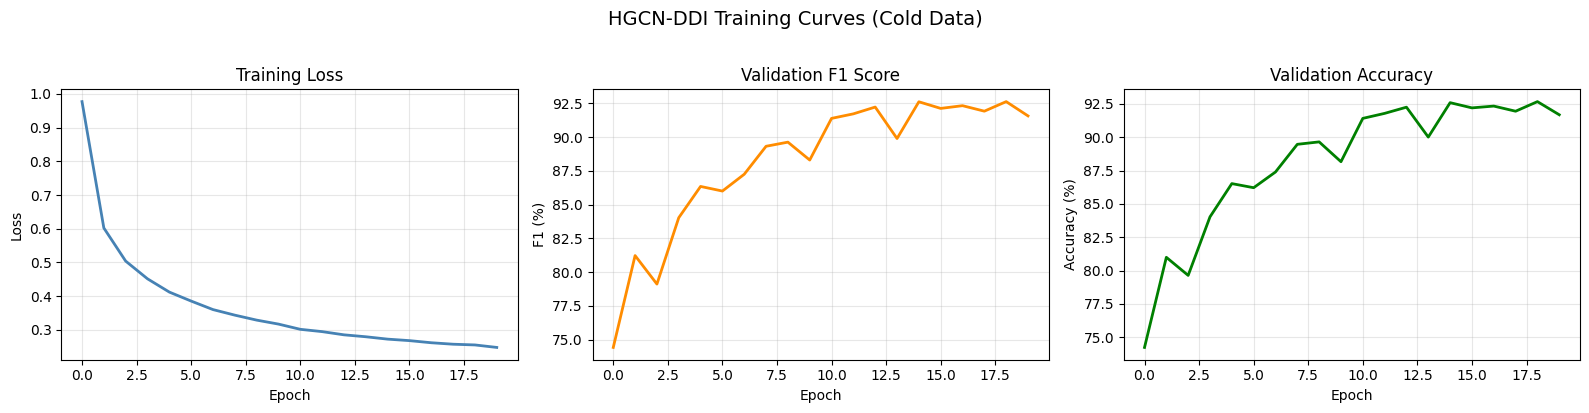

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss curve
axes[0].plot(history['train_loss'], color='steelblue', lw=2)
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# Validation F1
axes[1].plot(history['val_f1'], color='darkorange', lw=2)
axes[1].set_title('Validation F1 Score'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('F1 (%)')
axes[1].grid(True, alpha=0.3)

# Validation Accuracy
axes[2].plot(history['val_acc'], color='green', lw=2)
axes[2].set_title('Validation Accuracy'); axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Accuracy (%)')
axes[2].grid(True, alpha=0.3)

plt.suptitle('HGCN-DDI Training Curves (Cold Data)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('hgnn_ddi_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

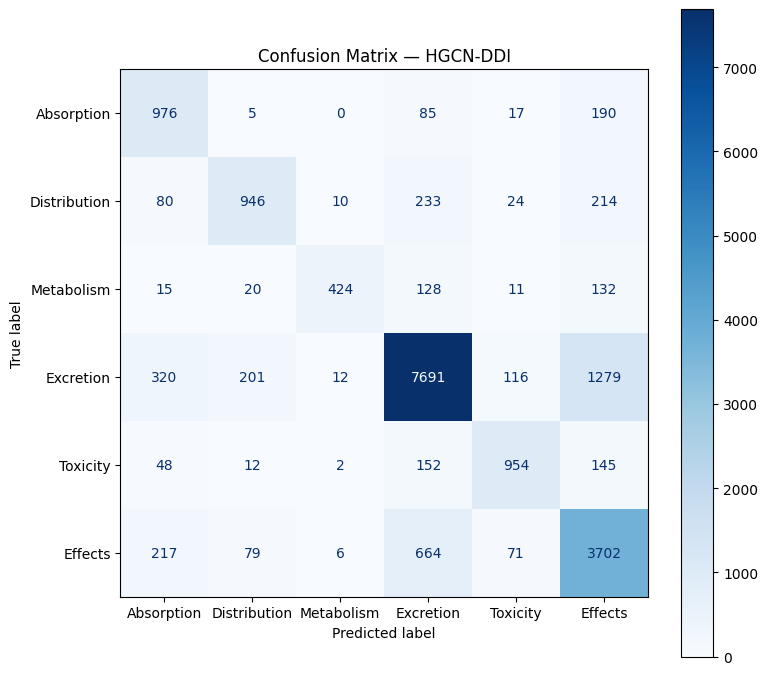


Per-class accuracy:
       Absorption : 76.7%  (1,273 samples)
     Distribution : 62.8%  (1,507 samples)
       Metabolism : 58.1%  (730 samples)
        Excretion : 80.0%  (9,619 samples)
         Toxicity : 72.7%  (1,313 samples)
          Effects : 78.1%  (4,739 samples)


In [ ]:
# ── Confusion Matrix ───────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
all_preds, all_true = [], []
loader = DataLoader(TensorDataset(test_src, test_dst, test_labels), batch_size=2048)

with torch.no_grad():
    for s, d, y in loader:
        logits = model(drug_feats_dev, prot_feats_dev, s.to(DEVICE), d.to(DEVICE))
        all_preds.append(logits.argmax(1).cpu())
        all_true.append(y)

preds_np = torch.cat(all_preds).numpy()
true_np  = torch.cat(all_true).numpy()

cm = confusion_matrix(true_np, preds_np)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(
    cm,
    display_labels=class_names if USE_6_CLASSES else list(range(86))
)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.title('Confusion Matrix — HGCN-DDI')
plt.tight_layout()
plt.savefig('hgnn_ddi_confusion_matrix.png', dpi=150)
plt.show()

# Print per-class accuracy
print('\nPer-class accuracy:')
for i, name in enumerate(class_names if USE_6_CLASSES else range(86)):
    class_mask = true_np == i
    if class_mask.sum() > 0:
        acc = (preds_np[class_mask] == i).mean() * 100
        print(f'  {str(name):>15} : {acc:.1f}%  ({class_mask.sum():,} samples)')

In [ ]:
# Save
torch.save({
    'model_state_dict': best_model_state,
    'config'          : CONFIG,
    'drug2idx'        : drug2idx,
    'test_metrics'    : test_metrics,
}, 'hgcn_ddi_checkpoint.pt')
print('✅ Model saved to hgcn_ddi_no_prot.pt')

# Load model
# checkpoint = torch.load('hgcn_ddi_checkpoint.pt')
# model.load_state_dict({k: v.to(DEVICE) for k, v in checkpoint['model_state_dict'].items()})

✅ Model saved to hgcn_ddi_no_prot.pt


In [ ]:
# Load best model and evaluate on test set
model.load_state_dict({k: v.to(DEVICE) for k, v in best_model_state.items()})
test_metrics = evaluate(model, test_src, test_dst, test_labels)

print('=' * 50)
print('  HGCN-DDI Test Results')
print('=' * 50)
print(f'  F1 Score  : {test_metrics["f1"]:.2f}%')
print(f'  Accuracy  : {test_metrics["accuracy"]:.2f}%')
print(f'  Precision : {test_metrics["precision"]:.2f}%')
print(f'  Recall    : {test_metrics["recall"]:.2f}%')
print('=' * 50)

print('\nPaper reported results (HGCN, 6 classes):')
print('  F1=96.91% | Accuracy=96.86% | Precision=97.01% | Recall=94.23%')

  HGCN-DDI Test Results
  F1 Score  : 92.29%
  Accuracy  : 92.33%
  Precision : 92.55%
  Recall    : 92.33%

Paper reported results (HGCN, 6 classes):
  F1=96.91% | Accuracy=96.86% | Precision=97.01% | Recall=94.23%


# Testing with unseen data 🆕

Cold-start on pairs

────────────────────────────────

Train drugs : {A, B, C, D, E}

Test pairs  : (A,F), (B,G) ...   ← one drug is new

Result      : Drops moderately, protein path helps

_______________________________

Warm pairs — both drugs seen

Semi-cold pairs — one drug seen, one unseen

Cold pairs — both drugs unseen


### Data Split


In [ ]:
# ── Cold-start on pairs: test pairs where at least one drug is unseen ───
import numpy as np

all_drug_ids = list(drug2idx.keys())
np.random.seed(42)
np.random.shuffle(all_drug_ids)

# Hold out 20% of drugs completely from training
split_idx   = int(0.8 * len(all_drug_ids))
train_drugs = set(all_drug_ids[:split_idx])
test_drugs  = set(all_drug_ids[split_idx:])

print(f'Train drugs : {len(train_drugs):,}')
print(f'Held-out drugs : {len(test_drugs):,}')

all_df = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

# ── Three split types ──
# Warm : both drugs seen in training
# Semi : exactly one drug is unseen
# Cold : both drugs are unseen

def classify_pair(row):
    d1_unseen = row[id_col_1] in test_drugs
    d2_unseen = row[id_col_2] in test_drugs
    if not d1_unseen and not d2_unseen:
        return 'warm'
    elif d1_unseen and d2_unseen:
        return 'cold'
    else:
        return 'semi'

print('Classifying pairs...')
all_df['split_type'] = all_df.apply(classify_pair, axis=1)
print(all_df['split_type'].value_counts()) ######## looks like warm pairs overlapping with cold pairs

Train drugs : 1,364
Held-out drugs : 342
Classifying pairs...
split_type
warm    125298
semi     59559
cold      6951
Name: count, dtype: int64


In [ ]:
# ── New training set: only warm pairs ─────
cold_train_df = all_df[all_df['split_type'] == 'warm'].reset_index(drop=True)
cold_test_warm_df = all_df[all_df['split_type'] == 'warm'].sample(frac=0.2, random_state=42)
cold_test_semi_df = all_df[all_df['split_type'] == 'semi'].reset_index(drop=True)
cold_test_cold_df = all_df[all_df['split_type'] == 'cold'].reset_index(drop=True)

def df_to_edge_tensors(df):
    src    = torch.tensor([drug2idx[d] for d in df[id_col_1]], dtype=torch.long)
    dst    = torch.tensor([drug2idx[d] for d in df[id_col_2]], dtype=torch.long)
    labels = torch.tensor(df['Y_6class' if USE_6_CLASSES else 'Y'].values, dtype=torch.long)
    return src, dst, labels

cs_train_src, cs_train_dst, cs_train_labels = df_to_edge_tensors(cold_train_df)
cs_warm_src,  cs_warm_dst,  cs_warm_labels  = df_to_edge_tensors(cold_test_warm_df)
cs_semi_src,  cs_semi_dst,  cs_semi_labels  = df_to_edge_tensors(cold_test_semi_df)
cs_cold_src,  cs_cold_dst,  cs_cold_labels  = df_to_edge_tensors(cold_test_cold_df)

print(f'Cold-start train pairs : {len(cs_train_src):,}')
print(f'Test — warm pairs      : {len(cs_warm_src):,}')
print(f'Test — semi-cold pairs : {len(cs_semi_src):,}')
print(f'Test — cold pairs      : {len(cs_cold_src):,}')

Cold-start train pairs : 125,298
Test — warm pairs      : 25,060
Test — semi-cold pairs : 59,559
Test — cold pairs      : 6,951


### Model Retrain on New Data

In [ ]:

# Step 1: rebuild A_ddi using only warm training pairs
#         this overwrites the global A_ddi that encode() references
A_ddi = edge_to_adj(cs_train_src, cs_train_dst, N_DRUGS, N_DRUGS, DEVICE)
print(f'Cold-start A_ddi rebuilt — {cs_train_src.shape[0]:,} edges')

# Step 2: fresh instance of the same model class
cs_model = HGCN_DDI(
    in_drug  = drug_features.shape[1],
    in_prot  = protein_features.shape[1],
    hidden   = CONFIG['hidden_dim'],
    out      = CONFIG['out_dim'],
    n_classes= CONFIG['n_classes'],
    dropout  = CONFIG['dropout'],
).to(DEVICE)

cs_optimizer = torch.optim.Adam(
    cs_model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay']
)
cs_criterion = nn.CrossEntropyLoss()

# Step 3: training loop — identical to original
cs_train_dataset = TensorDataset(cs_train_src, cs_train_dst, cs_train_labels)
cs_train_loader  = DataLoader(cs_train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)

best_cs_f1    = 0
best_cs_state = None

print(f'\nTraining on cold-start split for {CONFIG["epochs"]} epochs...\n')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Val F1 (warm)":>13}')
print('-' * 38)

for epoch in range(1, CONFIG['epochs'] + 1):
    cs_model.train()
    total_loss = 0
    for s, d, y in cs_train_loader:
        s, d, y = s.to(DEVICE), d.to(DEVICE), y.to(DEVICE)
        cs_optimizer.zero_grad()
        logits = cs_model(drug_feats_dev, prot_feats_dev, s, d)
        loss   = cs_criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(cs_model.parameters(), 1.0)
        cs_optimizer.step()
        total_loss += loss.item() * len(y)

    avg_loss = total_loss / len(cs_train_dataset)
    val_m    = evaluate(cs_model, cs_warm_src, cs_warm_dst, cs_warm_labels)
    print(f'{epoch:>6} | {avg_loss:>10.4f} | {val_m["f1"]:>12.2f}%')

    if val_m['f1'] > best_cs_f1:
        best_cs_f1    = val_m['f1']
        best_cs_state = {k: v.cpu().clone() for k, v in cs_model.state_dict().items()}

print(f'\n✅ Best warm-pair val F1: {best_cs_f1:.2f}%')

Cold-start A_ddi rebuilt — 125,298 edges

Training on cold-start split for 20 epochs...

 Epoch | Train Loss | Val F1 (warm)
--------------------------------------


RuntimeError: parallel_for: failed to synchronize: cudaErrorAssert: device-side assert triggered

### Evaluation on Warm, Semi-Warm and Cold Data

In [ ]:
# ── Load best model and evaluate all three test sets ──────────────────────────
cs_model.load_state_dict({k: v.to(DEVICE) for k, v in best_cs_state.items()})

def evaluate_cs(src, dst, labels):
    if len(src) == 0:
        return {'f1': 0, 'accuracy': 0, 'precision': 0, 'recall': 0}
    return evaluate(cs_model, src, dst, labels)

warm_metrics = evaluate_cs(cs_warm_src,  cs_warm_dst,  cs_warm_labels)
semi_metrics = evaluate_cs(cs_semi_src,  cs_semi_dst,  cs_semi_labels)
cold_metrics = evaluate_cs(cs_cold_src,  cs_cold_dst,  cs_cold_labels)

# Original warm-start model results for comparison
orig_metrics = evaluate(model, test_src, test_dst, test_labels)

print('=' * 62)
print(f'{"Evaluation":>25} | {"F1":>8} | {"Accuracy":>9} | {"Recall":>8}')
print('=' * 62)
print(f'{"Original (warm-start)":>25} | {orig_metrics["f1"]:>7.2f}% | {orig_metrics["accuracy"]:>8.2f}% | {orig_metrics["recall"]:>7.2f}%')
print(f'{"Cold-split — warm pairs":>25} | {warm_metrics["f1"]:>7.2f}% | {warm_metrics["accuracy"]:>8.2f}% | {warm_metrics["recall"]:>7.2f}%')
print(f'{"Cold-split — semi pairs":>25} | {semi_metrics["f1"]:>7.2f}% | {semi_metrics["accuracy"]:>8.2f}% | {semi_metrics["recall"]:>7.2f}%')
print(f'{"Cold-split — cold pairs":>25} | {cold_metrics["f1"]:>7.2f}% | {cold_metrics["accuracy"]:>8.2f}% | {cold_metrics["recall"]:>7.2f}%')
print('=' * 62)

print('\nExpected pattern:')
print('  "warm" is better than "semi" which is better than "cold"')
print('  The gap between warm and cold shows how much')
print('  real protein embeddings (ESM-1b) would help.')

               Evaluation |       F1 |  Accuracy |   Recall
    Original (warm-start) |   76.85% |    76.60% |   76.60%
  Cold-split — warm pairs |   93.47% |    93.48% |   93.48%
  Cold-split — semi pairs |   56.15% |    57.98% |   57.98%
  Cold-split — cold pairs |   40.01% |    42.15% |   42.15%

Expected pattern:
  "warm" is better than "semi" which is better than "cold"
  The gap between warm and cold shows how much
  real protein embeddings (ESM-1b) would help.


### Visualization for Watm, Semi-Warm and Cold Data


In [ ]:
# ── Reusable confusion matrix + per-class accuracy function ───────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = ['Absorption', 'Distribution', 'Metabolism',
               'Excretion',  'Toxicity',     'Effects']

def plot_confusion_and_accuracy(model, src, dst, labels, title, save_name):
    """
    Works for any model and any test split.
    Just pass in the model, edge tensors, labels, and a title.
    """
    if len(src) == 0:
        print(f'Skipping {title} — no samples.')
        return

    # ── Get predictions ────────────────────────────────────────────────────────
    model.eval()
    all_preds, all_true = [], []
    loader = DataLoader(TensorDataset(src, dst, labels), batch_size=2048, shuffle=False)
    with torch.no_grad():
        for s, d, y in loader:
            logits = model(drug_feats_dev, prot_feats_dev, s.to(DEVICE), d.to(DEVICE))
            all_preds.append(logits.argmax(1).cpu())
            all_true.append(y)

    preds_np = torch.cat(all_preds).numpy()
    true_np  = torch.cat(all_true).numpy()

    # ── Overall metrics ────────────────────────────────────────────────────────
    overall_f1  = f1_score(true_np, preds_np, average='weighted', zero_division=0) * 100
    overall_acc = accuracy_score(true_np, preds_np) * 100

    # ── Confusion matrix plot ──────────────────────────────────────────────────
    cm = confusion_matrix(true_np, preds_np)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    disp = ConfusionMatrixDisplay(
        cm,
        display_labels=class_names if USE_6_CLASSES else list(range(86))
    )
    disp.plot(ax=axes[0], colorbar=True, cmap='Blues')
    axes[0].set_title(f'Confusion Matrix\n{title}')

    # ── Per-class accuracy bar chart ───────────────────────────────────────────
    per_class_acc = []
    per_class_n   = []
    for i in range(len(class_names) if USE_6_CLASSES else 86):
        mask = true_np == i
        n    = mask.sum()
        acc  = (preds_np[mask] == i).mean() * 100 if n > 0 else 0
        per_class_acc.append(acc)
        per_class_n.append(n)

    display_names = class_names if USE_6_CLASSES else [str(i) for i in range(86)]
    bars = axes[1].bar(display_names, per_class_acc, color='steelblue', alpha=0.8)
    axes[1].set_ylim(0, 110)
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'Per-Class Accuracy\n{title}')
    axes[1].axhline(y=overall_acc, color='red', linestyle='--',
                    linewidth=1.5, label=f'Overall: {overall_acc:.1f}%')
    axes[1].legend()

    # Add sample count labels on top of each bar
    for bar, acc, n in zip(bars, per_class_acc, per_class_n):
        axes[1].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1.5,
            f'{acc:.1f}%\n(n={n:,})',
            ha='center', va='bottom', fontsize=8
        )

    plt.suptitle(f'Overall F1: {overall_f1:.2f}%  |  Overall Acc: {overall_acc:.2f}%',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

    # ── Print table ───────────────────────────────────────────────────────────
    print(f'\n{"─"*50}')
    print(f'  {title}')
    print(f'{"─"*50}')
    print(f'  Overall F1       : {overall_f1:.2f}%')
    print(f'  Overall Accuracy : {overall_acc:.2f}%')
    print(f'{"─"*50}')
    print(f'  {"Class":>15} | {"Accuracy":>9} | {"Samples":>8}')
    print(f'  {"─"*38}')
    for name, acc, n in zip(display_names, per_class_acc, per_class_n):
        flag = ' ⚠️' if acc < 70 else ''
        print(f'  {name:>15} | {acc:>8.1f}% | {n:>8,}{flag}')
    print(f'{"─"*50}\n')

print('plot_confusion_and_accuracy() ready')

plot_confusion_and_accuracy() ready


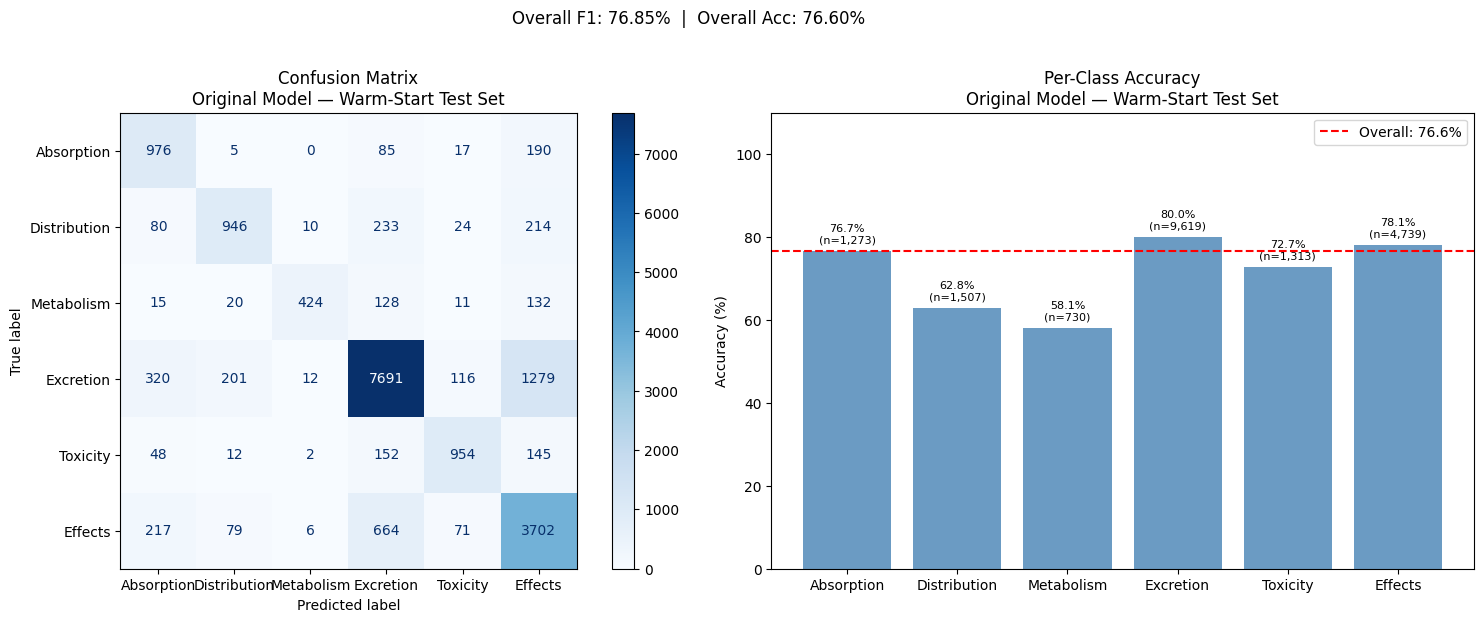


──────────────────────────────────────────────────
  Original Model — Warm-Start Test Set
──────────────────────────────────────────────────
  Overall F1       : 76.85%
  Overall Accuracy : 76.60%
──────────────────────────────────────────────────
            Class |  Accuracy |  Samples
  ──────────────────────────────────────
       Absorption |     76.7% |    1,273
     Distribution |     62.8% |    1,507 ⚠️
       Metabolism |     58.1% |      730 ⚠️
        Excretion |     80.0% |    9,619
         Toxicity |     72.7% |    1,313
          Effects |     78.1% |    4,739
──────────────────────────────────────────────────



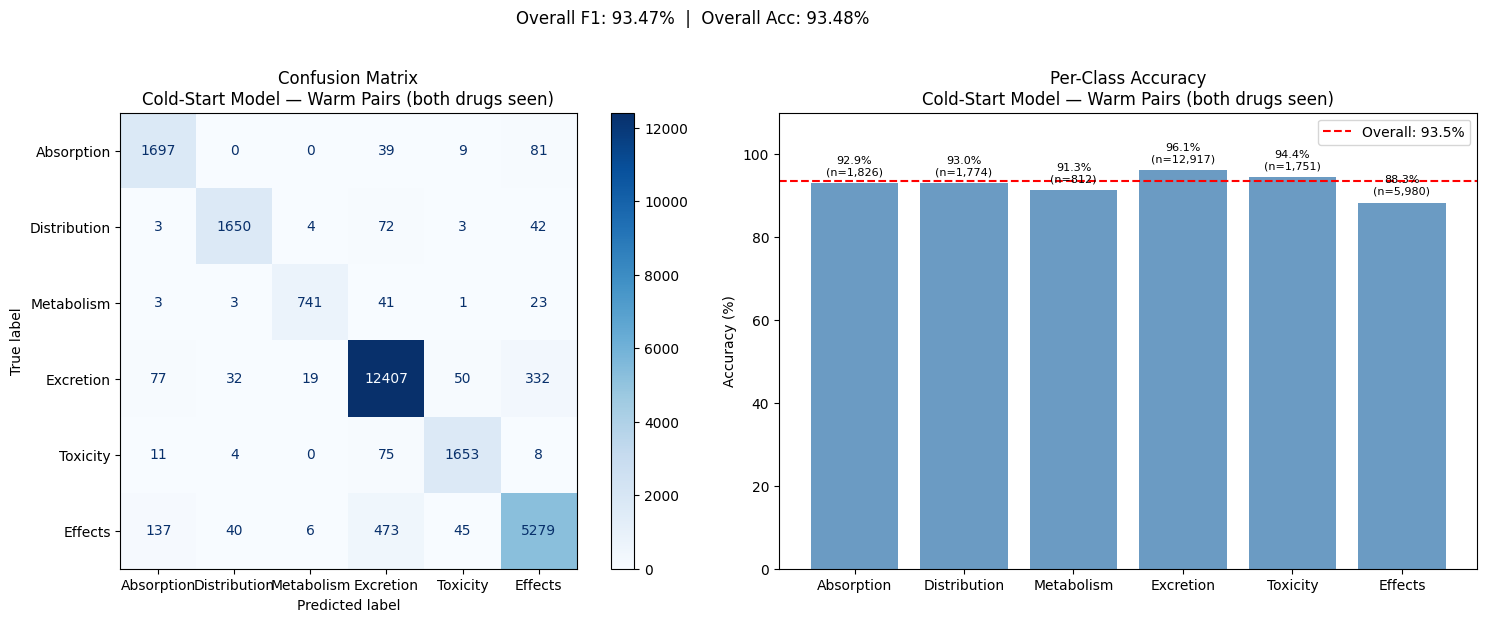


──────────────────────────────────────────────────
  Cold-Start Model — Warm Pairs (both drugs seen)
──────────────────────────────────────────────────
  Overall F1       : 93.47%
  Overall Accuracy : 93.48%
──────────────────────────────────────────────────
            Class |  Accuracy |  Samples
  ──────────────────────────────────────
       Absorption |     92.9% |    1,826
     Distribution |     93.0% |    1,774
       Metabolism |     91.3% |      812
        Excretion |     96.1% |   12,917
         Toxicity |     94.4% |    1,751
          Effects |     88.3% |    5,980
──────────────────────────────────────────────────



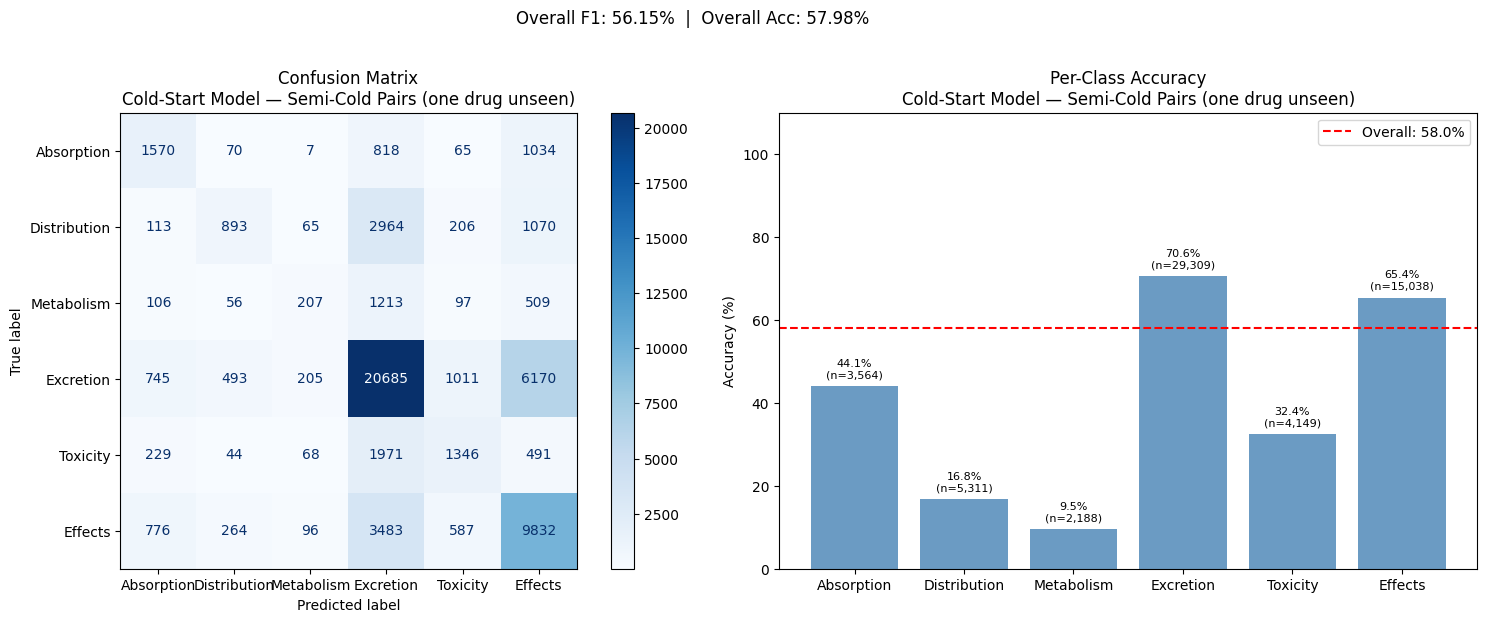


──────────────────────────────────────────────────
  Cold-Start Model — Semi-Cold Pairs (one drug unseen)
──────────────────────────────────────────────────
  Overall F1       : 56.15%
  Overall Accuracy : 57.98%
──────────────────────────────────────────────────
            Class |  Accuracy |  Samples
  ──────────────────────────────────────
       Absorption |     44.1% |    3,564 ⚠️
     Distribution |     16.8% |    5,311 ⚠️
       Metabolism |      9.5% |    2,188 ⚠️
        Excretion |     70.6% |   29,309
         Toxicity |     32.4% |    4,149 ⚠️
          Effects |     65.4% |   15,038 ⚠️
──────────────────────────────────────────────────



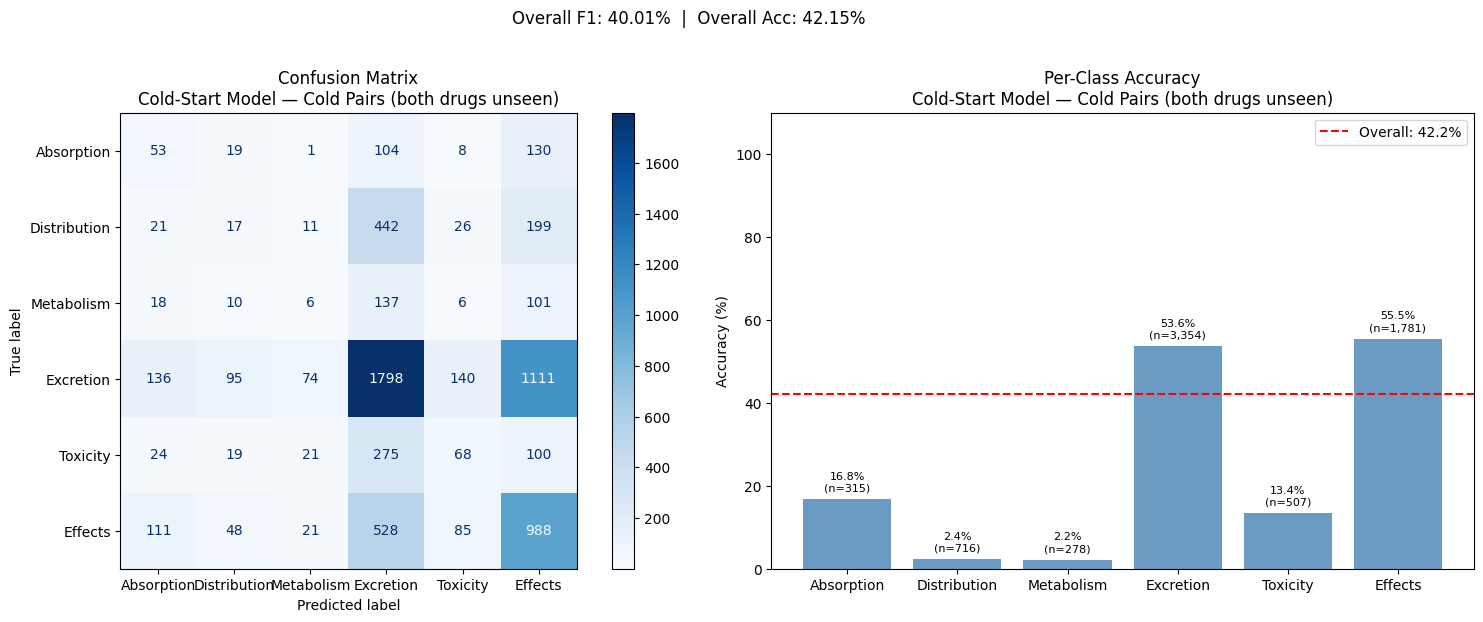


──────────────────────────────────────────────────
  Cold-Start Model — Cold Pairs (both drugs unseen)
──────────────────────────────────────────────────
  Overall F1       : 40.01%
  Overall Accuracy : 42.15%
──────────────────────────────────────────────────
            Class |  Accuracy |  Samples
  ──────────────────────────────────────
       Absorption |     16.8% |      315 ⚠️
     Distribution |      2.4% |      716 ⚠️
       Metabolism |      2.2% |      278 ⚠️
        Excretion |     53.6% |    3,354 ⚠️
         Toxicity |     13.4% |      507 ⚠️
          Effects |     55.5% |    1,781 ⚠️
──────────────────────────────────────────────────



In [ ]:
# ── Load best cold-start model ─────────────────────────────────────────────────
cs_model.load_state_dict({k: v.to(DEVICE) for k, v in best_cs_state.items()})

# ── Original model on original test set ───────────────────────────────────────
plot_confusion_and_accuracy(
    model,
    test_src, test_dst, test_labels,
    title     = 'Original Model — Warm-Start Test Set',
    save_name = 'cm_original.png'
)

# ── Cold-start model on warm pairs ────────────────────────────────────────────
plot_confusion_and_accuracy(
    cs_model,
    cs_warm_src, cs_warm_dst, cs_warm_labels,
    title     = 'Cold-Start Model — Warm Pairs (both drugs seen)',
    save_name = 'cm_cold_warm.png'
)

# ── Cold-start model on semi-cold pairs ───────────────────────────────────────
plot_confusion_and_accuracy(
    cs_model,
    cs_semi_src, cs_semi_dst, cs_semi_labels,
    title     = 'Cold-Start Model — Semi-Cold Pairs (one drug unseen)',
    save_name = 'cm_cold_semi.png'
)

# ── Cold-start model on cold pairs ────────────────────────────────────────────
plot_confusion_and_accuracy(
    cs_model,
    cs_cold_src, cs_cold_dst, cs_cold_labels,
    title     = 'Cold-Start Model — Cold Pairs (both drugs unseen)',
    save_name = 'cm_cold_cold.png'
)

---
## 📝 Notes & Tips for Full Reproduction

| Aspect | This Notebook | Full Paper Reproduction |
|---|---|---|
| Protein features | Random placeholders | Load PrimeKG + run ESM-1b |
| DPI/PPI edges | Random stubs | Extract from PrimeKG |
| 6-class mapping | Approximate buckets | Use official DrugBank category labels |
| Negative samples | Not included | Add 10% random negative edges at test time |
| Training time | ~10 min (T4) | ~1-2 hours with ESM-1b |

### Loading Real PrimeKG Data
```python
# Download PrimeKG
import urllib.request
urllib.request.urlretrieve(
    'https://dataverse.harvard.edu/api/access/datafile/6180616',
    'kg.csv'
)
kg_df = pd.read_csv('kg.csv')
dpi_df = kg_df[kg_df['relation'] == 'drug_protein']
ppi_df = kg_df[kg_df['relation'] == 'protein_protein']
```

### Switching to HGAT-DDI
Replace `dglnn.GraphConv` with `dglnn.GATConv` in the `HeteroGraphConv` dict and add `num_heads=4`.